# ESC SPMe: Plot I, V, T, and SOC for all cells

Note to self: currently set up to plot "fit" using 100A params with data input to illustrate error from using  wrong parameters  vs error propagation 

Conclusions: Because the model overpredicts current, I also let it overpredict temperature as opposed to tuning Cp and h to fit the data. Using the lumped thermal model, we see that the effect of decomposition heating is minimal, which was expected. SEI decomposition is also the only decomp reaction contributing to heating which was expected.  

In [5]:
# need to restart jupyter server? kernal? whenever a change is made to the pybamm module? 
import sys
import os
sys.path.insert(0,os.path.dirname(os.path.dirname(os.path.dirname(os.path.abspath("__file__")))))
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
# sys.path.insert(1,r'C:\Users\Vivian\Dropbox (University of Michigan)\from_box\Research\PyBaMM\PyBaMM\venv\Lib\MiKTeX')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# os.chdir(sys.path[0] + '\..') # change our working directory to the root of the pybamm folder
import pybamm
print(pybamm.__path__[0])
from scipy import integrate, constants
# import matplotlib
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': 'Computer Modern',
    'font.sans-serif': ['Computer Modern'],
    'font.size': 9,
})
%matplotlib widget
# pybamm.set_logging_level("INFO")

# reset plt settings
# import matplotlib as mpl
# mpl.rcParams.update(mpl.rcParamsDefault)
# pybamm.settings.max_smoothing = 'exact'

c:\Users\Vivian\Dropbox (University of Michigan)\from_box\Research\PyBaMM\PyBaMM\pybamm


In [6]:
class ExternalCircuitResistanceFunction():
    def __call__(self, variables):
        I = variables["Current [A]"]
        V = variables["Terminal voltage [V]"]
        R_ext = pybamm.FunctionParameter("External short resistance [Ohm]",  {"Time [s]": pybamm.t}) 
        R_tab = pybamm.FunctionParameter("Tabbing resistance [Ohm]",  {"Time [s]": pybamm.t})
        return V/I - (R_ext + R_tab)

# Define parameter functions

In [7]:
from pybamm import exp, constants, Parameter


def modified_graphite_diffusivity_PeymanMPM(sto, T):
    D_ref =  Parameter("Negative electrode diffusion coefficient [m2.s-1]")
    # D_ref = 16*5.0 * 10 ** (-15)
    # E_D_s = 42770
    # arrhenius = exp(E_D_s / constants.R * (1 / 298.15 - 1 / T))
    soc = (sto - 0)/(0.8321-0)
    k = 1.12070451*soc + 0.09209274 # Ds_restart_rmseV_11_simultaneous_rest (updated exp C-rate) only exclude kn>9

    # soc_fit = np.array([0.931499472,0.862995346,0.79449311,0.725995244,0.657493658,0.588993969,0.520494998,0.246491535,0.177990605,0.109487916][-1:0:-1])
    # k_fit = np.array([0.998960993,0.962562613,1.088848875,0.960830764,0.980577779,0.767837023,0.826562007,0.192714141,0.571586523,0.725658028][-1:0:-1])
    # x = [soc]
    # k = pybamm.Interpolant(soc_fit, k_fit, x, name=None, interpolator='linear', extrapolate=True, entries_string=None)
    
    return D_ref*k #*arrhenius # *(-0.9 * sto + 1)

def modified_NMC_diffusivity_PeymanMPM(sto, T):
    D_ref =  Parameter("Positive electrode diffusion coefficient [m2.s-1]")
    # E_D_s = 18550
    # arrhenius = exp(E_D_s / constants.R * (1 / 298.15 - 1 / T))
    soc = (0.837-sto)/(0.837-0.034)
    k =  4.7302281*soc**2  -4.5023245*soc + 1.26466141 # Ds_restart_rmseV_11_simultaneous_rest (updated exp C-rate)
    # soc_fit = np.array([0.931499472,0.862995346,0.79449311,0.725995244,0.657493658,0.588993969,0.520494998,0.451992894,0.383496394,0.31499461,0.246491535,0.109487916][-1:0:-1])
    # k_fit = np.array([1.224990159,0.918644845,0.646317414,0.418199795,0.250350793,0.318672366,0.267289649,0.182154457,0.11139899,0.329794626,0.337200374,0.418978523][-1:0:-1])
    # x = [soc]
    # k = pybamm.Interpolant(soc_fit, k_fit, x, name=None, interpolator='linear', extrapolate=True, entries_string=None)
    
    return D_ref *k #*arrhenius

def modified_electrolyte_diffusivity_PeymanMPM(c_e, T):
    # D_c_e = 5.35 * 10 ** (-10)
    D_c_e =  Parameter("Typical electrolyte diffusivity [m2.s-1]")
    return D_c_e

def modified_electrolyte_conductivity_PeymanMPM(c_e, T):
    # sigma_e = 1.3
    sigma_e = Parameter("Typical electrolyte conductivity [m2.s-1]")
    E_k_e = 34700
    return sigma_e


def modified_NMC_electrolyte_exchange_current_density_PeymanMPM(c_e, c_s_surf, c_s_max, T):
    m_ref =  Parameter("Positive electrode reference exchange-current density [A.m-2(m3.mol)1.5]")
    # m_ref = 4.824 * 10 ** (-6)  # (A/m2)(mol/m3)**1.5 - includes ref concentrations
    E_r = 39570
    arrhenius = exp(E_r / constants.R * (1 / 298.15 - 1 /T))

    return (
        m_ref * c_e**0.5 * c_s_surf**0.5 * (c_s_max - c_s_surf) ** 0.5 #* arrhenius
    )

def modified_graphite_electrolyte_exchange_current_density_PeymanMPM(c_e, c_s_surf, c_s_max, T):
    m_ref =  Parameter("Negative electrode reference exchange-current density [A.m-2(m3.mol)1.5]")
    # m_ref = 4*1.061 * 10 ** (-6)  # unit has been converted units are (A/m2)(mol/m3)**1.5 - includes ref concentrations
    E_r = 37480
    arrhenius = exp(E_r / constants.R * (1 / 298.15 - 1 / T))

    return (
        m_ref * c_e**0.5 * c_s_surf**0.5 * (c_s_max - c_s_surf) ** 0.5 #*arrhenius
    )


# Load data

In [8]:
# # # load data import ESC data from file
# t_end = 15*60
# raw_data = pd.read_csv("ESC_"+  '100B' + "SOC_full.csv")
# esc_start = raw_data[-raw_data['Current Shunt']>1].index[0]-1
# t_end_desired = raw_data['Time (s)'].loc[esc_start]+t_end
# esc_end = raw_data[(raw_data['Time (s)']>t_end_desired) | ((-raw_data['Current Shunt']<1) & (raw_data['Time (s)']>esc_start))].index[0]
# data = raw_data[['Time (s)', 'Voltage (V)', 'Cell Temperature', 'Current Shunt', 'Force']].loc[esc_start:esc_end].copy()
# data

In [12]:
Q_nom = 4.6
t_end = 15*60

def load_data(SOC_0, SOC_name):
    # load data import ESC data from file
    raw_data = pd.read_csv("ESC_"+  SOC_name + "SOC_full.csv")
    esc_start = raw_data[-raw_data['Current Shunt']>1].index[0]-1
    t_end_desired = raw_data['Time (s)'].loc[esc_start]+t_end
    esc_end = raw_data[(raw_data['Time (s)']>t_end_desired) | ((-raw_data['Current Shunt']<1) & (raw_data['Time (s)']>esc_start))].index[0]
    # T_amb = np.mean(raw_data['Cell Temperature'][(raw_data.index < esc_start) | (raw_data['Cell Temperature'] >0)])
    data = raw_data[['Time (s)', 'Voltage (V)', 'Cell Temperature', 'Current Shunt', 'Force']].loc[esc_start:esc_end].copy()
    data['Cell Temperature2'] = data['Cell Temperature'].copy() #make a copy 
    data['Cell Temperature'][data['Cell Temperature']>140] = None #filter and interpolate original
    data.interpolate(inplace=True) #fill in nans for df
    data['Cell Temperature2'][data['Cell Temperature2']>140] = None #filter copy, NO interp
    data['Current Shunt'] = -data['Current Shunt']
    data['Time (s)'] = data['Time (s)'] - data['Time (s)'].loc[esc_start]
    data['Force'] = data['Force']*9.81
    df_labels = ['t', 'V', 'Temp','I', 'F','Temp2']
    data.set_axis(df_labels, axis=1, inplace=True)
    data['I_C'] = data.I/Q_nom 
    AhT_calculated = integrate.cumtrapz(abs(data.I), data.t-data.t.iloc[0])/3600
    AhT_calculated = np.append(AhT_calculated,AhT_calculated[-1])
    data['SOC'] = SOC_0 - AhT_calculated/Q_nom # load data import ESC data from file
    if SOC_name =='100B':
        data['V'][(data.t[0:-1]>800) & (data.V>0.1)]  = None # remove voltage recovery on 100B

    T_amb_0 = np.mean(raw_data['Cell Temperature'][(raw_data.index < esc_start) & (raw_data['Cell Temperature'] >0)])
    data.reset_index(drop=True, inplace=True)

    return data, T_amb_0

display(load_data(1, '100A')[0])

C:\Users\Vivian\AppData\Local\Temp\ipykernel_15920\61062972.py:20: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `obj = obj.set_axis(..., copy=False)` instead
  data.set_axis(df_labels, axis=1, inplace=True)
C:\Users\Vivian\AppData\Local\Temp\ipykernel_15920\61062972.py:22: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  AhT_calculated = integrate.cumtrapz(abs(data.I), data.t-data.t.iloc[0])/3600


,t,V,Temp,I,F,Temp2,I_C,SOC
0,0.000,4.176052,24.111259,0.824988,135.614645,24.111259,0.179345,0.999296
1,0.100,1.564826,24.140908,232.204691,136.217933,24.140908,50.479281,0.997894
2,0.200,1.543099,24.121142,232.228600,136.313189,24.121142,50.484478,0.996493
3,0.300,1.521092,24.150790,231.838083,136.789469,24.150790,50.399583,0.995090
4,0.400,1.515830,24.121142,232.698815,136.789469,24.121142,50.586699,0.993685
...,...,...,...,...,...,...,...,...
8996,899.602,0.019834,69.558434,2.151935,10.098965,69.558434,0.467812,0.302791
8997,899.702,0.019834,69.548850,2.163890,10.225974,69.548850,0.470411,0.302777
8998,899.802,0.019754,69.568017,2.279450,9.971957,69.568017,0.495533,0.302764
8999,899.902,0.019874,69.548850,2.143966,10.416486,69.548850,0.466079,0.302751


# Run simulations

In [13]:
param_update_iso = {        
    "Negative electrode diffusivity [m2.s-1]": modified_graphite_diffusivity_PeymanMPM,
    "Positive electrode diffusivity [m2.s-1]": modified_NMC_diffusivity_PeymanMPM,
    "Electrolyte diffusivity [m2.s-1]": modified_electrolyte_diffusivity_PeymanMPM,
    "Electrolyte conductivity [S.m-1]": modified_electrolyte_conductivity_PeymanMPM,
    # "Initial concentration in electrolyte [mol.m-3]":1000, #*1.3
    "Negative electrode exchange-current density [A.m-2]": modified_graphite_electrolyte_exchange_current_density_PeymanMPM,
    "Positive electrode exchange-current density [A.m-2]": modified_NMC_electrolyte_exchange_current_density_PeymanMPM,
    "Negative electrode OCP entropic change [V.K-1]":0,
    "Positive electrode OCP entropic change [V.K-1]":0,
    }

In [42]:
# Cps = {'100A': 2.4847642158614396, '100B': 2.131841251256563, '75': 1.7615851440073333, '50': 1.8069119898506183}    # 12/31 test   T only, no weights
# hs = {'100A': 34.83874617168782, '100B': 34.211742173359575, '75': 37.17732764082647, '50': 35.31863975361435}   
# R_tabs = {'100A':  0.0086, '100B':0.0049, '75':0.0078+0.0005, '50':0.007}
# R_escs = {'100A':  0.0067, '100B':0.004, '75':0.0067-0.0005, '50':0.0067}
# # k_A_sei = {'100A':  0.07912785, '100B':0.238155, '75':0.04571944, '50':0.05716926}
# k_A_sei = {'100A': 0.13210066, '100B': 0.320855, '75': 0.06343707, '50':0.08423777}# k_A = 0.05716926 (MSE 1e-8 50%), k_A = 0.04571944 (MSE 1e-8 75%), k_A = 0.07912785(MSE 1e-8 100% t<80s), k_A = 0.238155 (MSE 1e-8 100F% t<53s)
 
# Cps.update({'avg': np.mean([Cps[k] for k in Cps.keys()])})
# hs.update({'avg': np.mean([hs[k] for k in hs.keys()])})
# R_tabs.update({'avg': np.mean([R_tabs[k] for k in R_tabs.keys()])})
# # R_tabs.update({'avg': 0})
# R_escs.update({'avg': np.mean([R_escs[k] for k in R_escs.keys()])})
# k_A_sei.update({'avg': np.mean([k_A_sei[k] for k in k_A_sei.keys()])})

In [47]:
def sim_ESC(SOC_0, SOC_name, param_update = {}, SOC_param = "", k_h_sei = 1):    # need to "data,T_amb_0 = load_data(SOC_0, SOC_name)" before running
    data, T_amb = load_data(SOC_0, SOC_name)
    R_tab = pybamm.Parameter("Tabbing resistance [Ohm]")
    R_ext = pybamm.Parameter("External resistance [Ohm]")
#     k_hs =[33.15978564710515, 32.06030657811052, 36.78712046658352, 36.67410927274155]
# k_Cps = [2.5383956970725863, 2.193498353654363, 1.7766323740122707, 1.7656000215073049]

    # [17.81984063  1.09465293] #100F%SOC w=0.1 for T>107, rhoend =1e-2, 15 min, MSE(e_dT)/M(dT),k0 = [18,1]
    # [19.99019775  1.20962392] #100%SOC w=0.1 for T>107, rhoend =1e-2, 15 min, MSE(e_dT)/M(dT),k0 = [18,1]
    # [19.81810618  0.96645967] #75%SOC w=0.1 for T>107, rhoend =1e-2, 15 min, MSE(e_dT)/M(dT),k0 = [18,1]
    # [20.00621175  1.0120845 ] #75%SOC w=0.1 for T>107, rhoend =1e-2, 15 min, MSE(e_dT)/M(dT),k0 = [18,1] 

    Cps = {'100A': 2.4847642158614396, '100B': 2.131841251256563, '75': 1.7615851440073333, '50': 1.8069119898506183}    # 12/31 test   T only, no weights
    hs = {'100A': 34.83874617168782, '100B': 34.211742173359575, '75': 37.17732764082647, '50': 35.31863975361435}   
    # Cps = {'100A': 2.5383956970725863, '100B': 2.193498353654363, '75': 1.7766323740122707, '50': 1.7656000215073049}    # 12/30 test   
    # hs = {'100A': 33.15978564710515, '100B': 32.06030657811052, '75': 36.78712046658352, '50': 36.67410927274155}   
    # R_tabs = {'100A':  0.0086, '100B':0.0049, '75':0.0078, '50':0.007}
    # R_escs = {'100A':  0.0067, '100B':0.004, '75':0.0067, '50':0.0067}
    # Cps = {'100A': 2.52552319, '100B': 2.20750941, '75': 1.83004138, '50': 1.79064985}    # 12/29 
    # hs = {'100A': 33.49523017, '100B': 33.09400724, '75': 36.77981673, '50': 35.70433857}
    # Cps = {'100A': 1.20962392, '100B': 1.09465293, '75': 0.96645967, '50': 1.0120845} # pre-12/28
    # hs = {'100A': 19.99019775, '100B': 17.81984063, '75': 19.81810618, '50': 20.00621175}
    R_tabs = {'100A':  0.0086, '100B':0.0049, '75':0.0078+0.0005, '50':0.007-0.0007}
    R_escs = {'100A':  0.0067, '100B':0.004, '75':0.0067-0.0005, '50':0.0067+0.0007}
    # k_A_sei = {'100A':  0.07912785, '100B':0.238155, '75':0.04571944, '50':0.05716926}
    k_A_sei  = {'100A': 0.13210066, '100B': 0.320855, '75': 0.06343707, '50':0.08423777}# k_A = 0.05716926 (MSE 1e-8 50%), k_A = 0.04571944 (MSE 1e-8 75%), k_A = 0.07912785(MSE 1e-8 100% t<80s), k_A = 0.238155 (MSE 1e-8 100F% t<53s)

    # calc avg value
    Cps.update({
        'avg': np.mean([Cps[k] for k in Cps.keys()]),
        # 'avg vent': np.mean([Cps['100A'],Cps['100B'] ]),
        # 'avg no vent': np.mean([Cps['75'],Cps['50'] ]),
        })
    hs.update({
        'avg': np.mean([hs[k] for k in hs.keys()]),
        # 'avg vent': np.mean([hs[k] for k in hs.keys()]),
        # 'avg no vent': np.mean([hs[k] for k in hs.keys()]),
        })
    R_tabs.update({
        'avg': np.mean([R_tabs[k] for k in R_tabs.keys()]),
        # 'avg':0,
        # 'avg vent': np.mean([R_tabs[k] for k in R_tabs.keys()]),
        # 'avg no vent': np.mean([R_tabs[k] for k in R_tabs.keys()]),
        })
    R_escs.update({
        'avg': np.mean([R_escs[k] for k in R_escs.keys()]),
        # 'avg vent': np.mean([R_escs[k] for k in R_escs.keys()]),
        # 'avg no vent': np.mean([R_escs[k] for k in R_escs.keys()]),
        })
    k_A_sei.update({
        'avg': np.mean([k_A_sei[k] for k in k_A_sei.keys()]),
        # 'avg vent': np.mean([k_A_sei[k] for k in k_A_sei.keys()]),
        # 'avg no vent': np.mean([k_A_sei[k] for k in k_A_sei.keys()]),
        })

    if SOC_param =="":
        SOC_param = SOC_name
    option = {
        "thermal": "lumped",
        "decomposition": "true", 
        "operating mode": ExternalCircuitResistanceFunction(),
        "cell geometry": "arbitrary",
        "venting":"true",
        # "loss of active material": "electrolyte dryout", 
    }

    model = pybamm.lithium_ion.SPMe(options = option)
    chemistry = pybamm.parameter_sets.Tran2023
    param = pybamm.ParameterValues(chemistry)
    # var_pts = model.default_var_pts
    # var_pts.update({
    #     'R_n':60,
    #     'R_p':60,
    # })
    param.update({
        # "Initial fraction of Li in SEI": 0.15,
        "Frequency factor for SEI decomposition [s-1]": 1.67E15*k_A_sei['100A'],
        "Enthalpy of SEI decomposition [J.kg-1]":257000*k_h_sei,
        # "Number of electrodes connected in parallel to make a cell": 10,
        'Internal short resistance [Ohm]':1e16,
        "Tabbing resistance [Ohm]":  R_tabs[SOC_name],#0.0041,D
        "External short resistance [Ohm]": R_escs[SOC_name], # 0.0067
        "Cell capacity [A.h]": 4.6, #nominal
        "Typical current [A]": 4.6,
        "Negative electrode thickness [m]":62E-06*4.2/5,
        "Positive electrode thickness [m]":67E-06*4.2/5,
        "Lower voltage cut-off [V]": 0,
        "Ambient temperature [K]":T_amb + 273.15,
        "Initial temperature [K]": T_amb + 273.15,
        # "Negative tab width [m]":2.5e-2,
        # "Positive tab width [m]":2.5e-2,
        "Initial cell compression stress [kPa]": data['F'].iloc[0]/param['Active material surface area [m2]']/1000,
        "Total heat transfer coefficient [W.m-2.K-1]":hs['100A'],
        "Negative electrode specific heat capacity [J.kg-1.K-1]": 1100*Cps['100A'],
        "Positive electrode specific heat capacity [J.kg-1.K-1]": 1100*Cps['100A'],
    }, check_already_exists = False)

    param.update(param_update, check_already_exists = False)
    
    V = model.variables["Terminal voltage [V]"]
    I = model.variables["Current [A]"]
    model.variables.update({
        "Terminal voltage [V]": V - I*R_tab,
        "Actual resistance [Ohm]":V/I,
        }
    )
    
    dt = 0.1
    t_eval = np.arange(0, t_end, dt) #16*60
    solver = pybamm.CasadiSolver(mode="safe", dt_max = 10) #, extra_options_setup={"max_num_steps": 10000}
    sim = pybamm.Simulation(model, parameter_values = param, solver=solver) # var_pts=var_pts
    solution = sim.solve( initial_soc=SOC_0, t_eval = t_eval)
    return solution

# solution = sim_ESC(0.75, '75')


In [48]:
SOC_names = ['100A', '100B', '75', '50']
# SOC_names = ['75', '50']

SOC_0s = {'100A': 1, '100B': 1, '75': 0.75, '50': 0.5}

datas = []
T_ambs = []
solutions_fit = []

for SOC_name in SOC_names: 
    print(SOC_name)

    # load data and sim 
    SOC_0 = SOC_0s[SOC_name]
    data,T_amb = load_data(SOC_0, SOC_name)
    solution_fit = sim_ESC(SOC_0, SOC_name, param_update = param_update_iso, SOC_param = '100A')
    solutions_fit.append(solution_fit)
    
    datas.append(data)
    T_ambs.append(T_amb)


100B
75
50


In [49]:
# save sim results to csv for matlab plotting
for (sol, soc_name) in zip(solutions_fit, SOC_names):
    t = sol["Time [s]"].entries
    I = sol['Current [A]'](t=t)
    V = sol['Terminal voltage [V]'](t=t)
    T = sol['Volume-averaged cell temperature [K]'](t=t)
    print(max(T)-273.15)
    x_sei = sol['Fraction of Li in SEI'](t=t)

    sim_results = pd.DataFrame.from_dict({'t':t, 'I':I, 'V':V, "T":T, 'x_sei':x_sei})
    sim_results.to_csv(r'C:\Users\Vivian\University of Michigan Dropbox\Vivian Tran\from_box\Research\PyBaMM\PyBaMM\pybamm_simulink\model_validation\pybamm_ESC_sim_results\pybamm_' + soc_name +'_ESC_sim_results.csv')


135.92247894645823
138.80330395288337
100.29783584502513
67.54903499945652


## Run thermal model sim with data input

In [14]:
# def ocv(soc): # from hppc rest with 11th-order polynomial 
#     p0 = np.array([0.114319142120841,  -0.663997904709863, 
#             1.686768366470837,  -2.462409468590447,   2.282769243949050, 
#             -1.401600551327618,   0.576551904459066,  -0.157044814050174, 
#             0.027351974716897,  -0.002866912229499,   0.000171009483610,
#             0.000029999998915])*1e5
#     return np.polyval(p0,soc)

def ocv(soc): # from C/10 with 15th-order polynomial 
    p0 = np.array([0.018506268107831,  -0.136071028323453, 
            0.443060938604833,  -0.839776753517996,   1.024213621638298, 
            -0.839264034243947,   0.470188190051651,  -0.183011124631359, 
            0.053509361841394,  -0.015162911494282,   0.005025031383283,
            -0.001474328544519, 0.000287406587189, -0.000032455129489, 
            0.000001937547848,  0.000000299017470
        ])*1e7
    return np.polyval(p0,soc)

In [15]:
def sim_thermal(h,Cp, SOC_0, T_amb_0, t, I, dV):  
# def sim_thermal_fitting(h,Cp, SOC_0, T_amb_0, t,Q):  

    chemistry = pybamm.parameter_sets.Tran2023
    param = pybamm.ParameterValues(chemistry)

    param.update({
        "Ambient temperature [K]":T_amb_0 + 273.15,
        "Initial temperature [K]": T_amb_0 + 273.15,
        "Negative tab width [m]":2.5e-2,
        "Positive tab width [m]":2.5e-2,
        # "Edge heat transfer coefficient [W.m-2.K-1]":h,
        "Total heat transfer coefficient [W.m-2.K-1]":h,
        "Negative electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
        "Positive electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
        "Cell open circuit voltage [V]": ocv,
        "Cell capacity [A.h]": 4.6, #nominal
        "Typical current [A]": 4.6,
        "Negative electrode thickness [m]":62E-06*4.2/5,
        "Positive electrode thickness [m]":67E-06*4.2/5,
    }, check_already_exists = False)

    # Define input and output
    Q_vol_av = pybamm.Variable("Volume-averaged total heating")
    T_vol_av= pybamm.Variable("Volume-averaged cell temperature")

    # Init model and variables
    liion = pybamm.LithiumIonParameters()
    model = pybamm.BaseModel()
    Delta_T = param.evaluate(liion.Delta_T)
    T_ref = param.evaluate(liion.T_ref)
    tau_discharge = param.evaluate(liion.tau_discharge)
    tau_th_yz = param.evaluate(liion.tau_th_yz)
    model.timescale = pybamm.Scalar(tau_discharge)
    model.variables = {
        "Volume-averaged total heating": Q_vol_av, 
        "Volume-averaged cell temperature": T_vol_av,
        "Volume-averaged cell temperature [K]": Delta_T * T_vol_av + T_ref,
    }
    model.external_variables = [Q_vol_av]

    # Set up parameters
    # thermal = pybamm.thermal_parameters
    delta = param.evaluate(liion.delta) #self.L_x / self.L_z
    cell_surface_area = param.evaluate(liion.a_cooling) #self.A_cooling / (self.L_z ** 2)
    cell_volume = param.evaluate(liion.v_cell) # self.V_cell / (self.L_x * self.L_z ** 2)
    h_total = param.evaluate(liion.h_total) # self.h_total_dim * self.geo.L_x / self.lambda_eff_dim_ref
    rho = param.evaluate(liion.rho(T_vol_av)) # Dimensionless effective density? self.rho_dim(T_dim) * self.c_p_dim(T_dim) / self.main_param.rho_eff_dim_ref
    T_amb = param.evaluate(liion.T_amb(0)) # (self.T_amb_dim(t) - self.T_ref) / self.Delta_T
    total_cooling_coefficient = (
        -h_total
        * cell_surface_area
        / cell_volume
        / (delta ** 2))
    B = param.evaluate(liion.B) #self.B = (self.i_typ* self.R* self.T_ref* self.tau_th_yz/ (self.therm.rho_eff_dim_ref * self.F * self.Delta_T * self.L_x))
    C_th = param.evaluate(liion.tau_th_yz)/param.evaluate(liion.tau_discharge) # self.tau_th_yz / self.timescale
    Q_scale = param.evaluate(liion.i_typ) * param.evaluate(liion.potential_scale) / param.evaluate(liion.L_x)


    model.variables.update({
    "Volume-averaged total heating [W.m-3]": Q_vol_av * Q_scale,
    })

    # RHS
    model.rhs = {
        T_vol_av: (
            B * Q_vol_av + total_cooling_coefficient * (T_vol_av - T_amb)
        )/ (C_th * rho)
    }
    
    # set initial conditions
    T_init = param.evaluate(liion.T_init)
    model.initial_conditions = {T_vol_av: pybamm.Scalar(T_init)}

    # discretize
    disc = pybamm.Discretisation()  # use the default discretisation
    disc.process_model(model)

    # set Q as external variable
    Q_data = I*dV #(ocv(soc)-V)

    # solve
    sim = pybamm.Simulation(model)
    V_cell_norm = param.evaluate(liion.L) *param.evaluate(liion.L_y) *param.evaluate(liion.L_z) 
    for i,q in enumerate(Q_data[0:-1]):
    # for i,q in enumerate(Q[0:-1]):
        dt = t[i+1]-t[i]
        external_variables = {"Volume-averaged total heating": q/V_cell_norm/Q_scale} 
        sim.step(dt, external_variables=external_variables)
    return sim


In [16]:
solutions_thermal_fit = []
for j, (SOC_name,data, T_amb, solution_pybamm_model) in enumerate(zip(SOC_names, datas, T_ambs, solutions_fit)):
    print(SOC_name)
    # h = hs[SOC_name]
    # Cp = Cps[SOC_name]
    h = hs['100A']
    Cp = Cps['100A']
    SOC_0 = SOC_0s[SOC_name]
    sim_data_input = sim_thermal(h,Cp, SOC_0, T_amb, data.t, data.I,(ocv(data.SOC)-data.V))#V_ocv-V with I and Vt from data
    solutions_thermal_fit.append(sim_data_input.solution)

100A
100B
75
50


## Run venting model sim with data input

In [17]:
def P_sat(T):
    P_dmc = 10**(6.4338-1413.0/(T-44.25))
    P_ec = 10**(6.4897-1836.57/(T-102.23))
    P = P_dmc*0.7 + P_ec*0.3  
    # P = exp(18.55524-8661.40659/(T+270.16157)) #Qin et al 2021
    return P

def sim_venting(k_A, t, T_in, T_amb_0, F0):
    # if k_A >0.9:
    #     pybamm.settings.max_smoothing = 0.2
    # else:
    #     pybamm.settings.max_smoothing = "exact"
   
    chemistry = pybamm.parameter_sets.Tran2023
    param = pybamm.ParameterValues(chemistry)
    
    if np.isnan(F0):
        P0_sim =  data['F'].iloc[0]/param['Active material surface area [m2]']/1000
    else:
        P0_sim = F0/param['Active material surface area [m2]']/1000
    param.update({
        "Initial fraction of Li in SEI": 0.15, #*k_sei,
        "Frequency factor for SEI decomposition [s-1]": 1.67E15*k_A,
        "Cell capacity [A.h]": 4.6, #nominal
        "Typical current [A]": 4.6,
        "Negative electrode thickness [ m]":62E-06*4.2/5,
        "Positive electrode thickness [m]":67E-06*4.2/5,
        "Initial cell compression stress [kPa]": P0_sim,
        "Critical venting pressure [kPa]": max(158.7731,(max(data['F']) )/param['Active material surface area [m2]']/1000 + 101)
        
    }, check_already_exists = False)

    # Define input and output
    T_vol_av = pybamm.Variable("Volume-averaged cell temperature [K]")
    x_sei = pybamm.Variable("Fraction of Li in SEI")
    delta_sigma = pybamm.Variable("Cell expansion stress [kPa]")

    # Init model and variables
    model = pybamm.BaseModel()
    model.variables = {
        "Volume-averaged cell temperature [K]": T_vol_av,
        "Fraction of Li in SEI": x_sei,
        "Cell expansion stress [kPa]": delta_sigma,
    }
    model.external_variables = [T_vol_av]

    # Set up parameters
    thermal = pybamm.thermal_parameters
    k_b = constants.k_b

    r_sei_dimensional = (
        -param.evaluate(thermal.A_sei)
        * x_sei
        * pybamm.exp(-param.evaluate(thermal.E_sei) / (k_b * T_vol_av))
    )  # units 1/s

    model.variables.update({
            "SEI decomposition reaction rate [s-1]": r_sei_dimensional,
        })

    # VENTING SUBMODEL
    P_crit = param.evaluate(thermal.P_crit)
    m_an = param.evaluate(thermal.m_an)
    x_sei_0 = param.evaluate(thermal.x_sei_0)
    M_C6 = param.evaluate(thermal.M_an)
    V_head_0 = param.evaluate(thermal.V_head_0)
    A_surf = param.evaluate(thermal.A_surf)
    L = param.evaluate(thermal.L_poron)
    E = param.evaluate(thermal.E_poron)
    alpha_cell = param.evaluate(thermal.alpha_cell)
    sigma_0 = param.evaluate(thermal.sigma_0)
    P_atm = param.evaluate(thermal.P_atm)
    delta_d = L/E*delta_sigma
    T_amb = T_amb_0 +273.15 # param.evaluate(thermal.T_amb_dim(0)) #no effect on venting
    delta_T = T_vol_av-T_amb
    V_head = V_head_0 + A_surf*(delta_d-alpha_cell*delta_T)   
    # P_dmc = 10**(6.4338-1413.0/(T_vol_av-44.25))
    # P_ec = 10**(6.4897-1836.57/(T_vol_av-102.23)) 
    # P_sat_e = P_dmc*0.7 + P_ec*0.3 
    P_sat_e = P_sat(T_vol_av)
    n_CO2 = m_an*(x_sei_0 - x_sei)/(2*M_C6)
    P_CO2 = n_CO2*constants.R*T_vol_av/V_head/1000 #pybamm.minimum(n_CO2*constants.R*T_vol_av/V_head/1000, P_crit*2) #kPa
    P_gas =  P_CO2 + P_sat_e 

    model.variables.update({
        "Thermal expansion stress of active material [kPa]": E*alpha_cell*delta_T/L,
        "Electrolyte gas saturation pressure [kPa]": P_sat_e,
        "CO2 gas pressure [kPa]": P_CO2,
        "Total gas pressure [kPa]": P_gas,
        "Amount of CO2 generated [mol]": n_CO2,
        "Headspace volume [m3]": V_head,
    })

    # RHS
    model.rhs = {
        x_sei: r_sei_dimensional,
    }
    model.algebraic = {
        delta_sigma: delta_sigma - pybamm.maximum(P_gas-P_atm-sigma_0, E*alpha_cell*delta_T/L),
        }

    # set initial conditions
    model.initial_conditions = {
        x_sei: param.evaluate(thermal.x_sei_0),
        delta_sigma: pybamm.Scalar(0),
        }

    # discretize
    disc = pybamm.Discretisation()  # use the default discretisation
    disc.process_model(model)

    # solve
    sim = pybamm.Simulation(model)

    for i,T in enumerate(T_in[0:-1]+273.15):
        dt = t[i+1]-t[i]
        external_variables = {"Volume-averaged cell temperature [K]": T}
        sim.step(dt, external_variables=external_variables)

    return sim

In [18]:
solutions_venting_fit = []
for j, (SOC_name,data, T_amb) in enumerate(zip(SOC_names, datas, T_ambs)):
    print(SOC_name)
    # k_A = k_A_sei[SOC_name]
    k_A = k_A_sei['100A']
    SOC_0 = SOC_0s[SOC_name]
    sim_data_input = sim_venting(k_A, data.t, data.Temp,T_amb, data.F.iloc[0])#V_ocv-V with I and Vt from data
    solutions_venting_fit.append(sim_data_input.solution)
    #print fraction of x_sei remaining
    print(min(sim_data_input.solution["Fraction of Li in SEI"].entries)/0.15)

# use T from solution_thermal_fit
#(100B: "Could not find consistent states: Could not find acceptable solution: solver returned NaNs". b/c x_sei->0?) 
# solutions_venting_fit = []
# for j, (SOC_name,solution_thermal_fit, T_amb) in enumerate(zip(SOC_names, solutions_thermal_fit, T_ambs)):
#     # try:
#     print(SOC_name)
#     k_A = k_A_sei[SOC_name]
#     SOC_0 = SOC_0s[SOC_name]
#     t = data.t
#     T = solution_thermal_fit["Volume-averaged cell temperature [K]"](t=t.iloc[0:-1])-273.15 # input T in degC
#     sim_data_input = sim_venting(k_A, t, T,T[0], data.F.iloc[0])#V_ocv-V with I and Vt from data
#     solutions_venting_fit.append(sim_data_input.solution)
#     # except:
#     #     solutions_venting_fit.append(np.nan)
    

100A
0.9407818483521518
100B
0.9658824837530988
75
0.9897806592570528
50
0.9933038459776921


# PLOT: Simulation with average and fitted values

## Linear time with inset

2024-05-23 17:51:41.416 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-05-23 17:51:41.432 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-05-23 17:51:41.433 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-05-23 17:51:41.435 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-05-23 17:51:41.436 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-05-23 17:51:41.437 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-05-23 17:51:41.449 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-05-23 17:51:41.516 - [WARNING] processed_variable.__call__(459): Calling varia

1
8.174146397870018
1
12.152107150530156
0.75
10.330364387100795
0.5


2024-05-23 17:51:41.618 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-05-23 17:51:41.618 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-05-23 17:51:41.618 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-05-23 17:51:41.618 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-05-23 17:51:41.618 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-05-23 17:51:41.618 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-05-23 17:51:41.647 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')


11.111891096909815


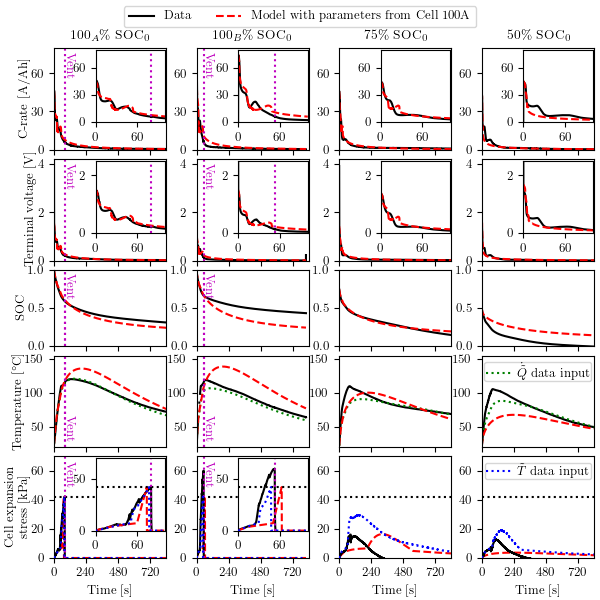

,SOC_names,dSOCs_f,dT_maxs,dsigma_maxs,dt_vents,rmses_I,rmses_V,rmses_T,rmses_sigma
0,100A,-0.07,15.64,-0.35,-6.1,1.18,0.04,13.49,6.97
1,100B,-0.19,19.98,-18.00,10.1,2.27,0.05,23.85,26.71
2,75,0.06,-9.52,0.28,10.1,1.29,0.05,9.17,0.73
3,50,0.15,-38.02,-8.93,10.1,1.67,0.04,19.92,2.33


In [34]:
%matplotlib widget
# plt.rcParams.update({
#     'font.size': 11,
# })
param = pybamm.ParameterValues('Tran2023')
param.update({
    "Negative electrode thickness [m]":62E-06*4.2/5,
    "Positive electrode thickness [m]":67E-06*4.2/5,
}, check_already_exists = False)
L_y = param.evaluate(pybamm.geometric_parameters.L_y)
L_z = param.evaluate(pybamm.geometric_parameters.L_z)
L = param.evaluate(pybamm.geometric_parameters.L)
V_cell = L*L_y*L_z
delta_sigma_max = 42.35277961

sim_set_labels = ['Model with parameters from Cell 100A']
fit_labels=[r'$\dot{{\tilde{Q}}}$ data input', r'$\tilde{T}$ data input'] #=$\tilde{I}\Delta$V 
# fig, ax= plt.subplots(5, len(SOC_names), figsize=(6.75, 7), sharex=True) #, , gridspec_kw = {'wspace':0.4, 'hspace':0.15}, ,constrained_layout=True # paper 
# plt.subplots_adjust(left=0.09, bottom=0.07, right=0.99, top=0.925, wspace=0.27, hspace=0.1)

# ECS poster
fig, ax= plt.subplots(5, len(SOC_names), figsize=(6, 6), sharex=True, height_ratios=[1,1,0.75,.9, 1]) #, , gridspec_kw = {'wspace':0.4, 'hspace':0.15}, ,constrained_layout=True # paper 
plt.subplots_adjust(left=0.09, bottom=0.07, right=0.99, top=0.92, wspace=0.27, hspace=0.1)

ax_inset = ax.copy()
# ax = ax.flatten()
linestyles = ['--',':','-.']
sim_colors = ['r','b','g']
fit_colors = ['g','b']
ls_data_input = ':'

# init metric logging
SOC_names_list = []
dSOCs_f = []
dT_maxs = []
dsigma_maxs = []
rmses_I = []
rmses_V = []
rmses_T = []
rmses_sigma = []
dt_vents = []

# for each cell...
for k, solutions in enumerate([solutions_fit]): 
    for j, (solution,solution_thermal_fit,solution_venting_fit, data) in enumerate(zip(solutions, solutions_thermal_fit, solutions_venting_fit, datas)):    

        # sim plot vars
        SOC_0 = SOC_0s[SOC_names[j]]
        print(SOC_0)
        t = data.t #solution["Time [s]"].entries
        I = solution['C-rate'](t=t)
        I_A = solution['Current [A]'](t=t)
        Vt = solution["Terminal voltage [V]"](t=t)
        AhT_calculated = integrate.cumtrapz(abs(I), t)/3600
        AhT_calculated = np.append(AhT_calculated,AhT_calculated[-1])
        SOC = SOC_0- AhT_calculated
        T = solution['Volume-averaged cell temperature [K]'](t=t) - 273.15
        Q = solution['Volume-averaged total heating [W.m-3]'](t=t)*V_cell
        delta_sigma = solution["Cell expansion stress [kPa]"](t)

        # plot settings
        data_color = 'k'
        sim_color = sim_colors[k]
        sim_ls = '--'
        t_end_inset = 100
        inset_pos = [.37, .27, 1-0.01-0.37, 1-0.02-.27] #[x0, y0, width, height]

        sigma_0 = data['F'].iloc[0]/param['Active material surface area [m2]']/1000,
        data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0

        if k ==0: 
            ax[0,j].plot(data.t,data.I/param['Nominal cell capacity [A.h]'], label='Data',color = data_color)
            ax[0,j].set_yticks(np.arange(0,80,30))
            ax_inset[0,j] = ax[0,j].inset_axes(inset_pos, xlim = (0,t_end_inset), ylim = (0,80), xticks=[0,60], yticks=np.arange(0,80,30))  # subregion of original plot yticklabels=[]
            ax_inset[0,j].plot(data.t,data.I/param['Nominal cell capacity [A.h]'], label='Data',color = data_color)

            ax[1,j].plot(data.t, data.V, color = data_color)
            ax_inset[1,j] = ax[1,j].inset_axes(inset_pos, xlim = (0,t_end_inset), ylim = (0,2.5), xticks=[0,60])  # subregion of original plot yticklabels=[]
            ax_inset[1,j].plot(data.t,data.V, label='Data',color = data_color)
            
            ax[2,j].plot(data.t, data.SOC, color = data_color)

            ax[3,j].plot(data.t, data.Temp2,  color = data_color)
            ax[3,j].plot(data.t, solution_thermal_fit['Volume-averaged cell temperature [K]'](t=t) - 273.15,  linestyle= ls_data_input, color = fit_colors[0], label=fit_labels[0])

            ax[3,j].set_xticks(np.arange(0, 60*14, 60*4))
            if j == len(solutions_thermal_fit)-1:
                ax[3,j].legend(borderpad = 0.1, loc='upper center', handletextpad = 0.5)
            delta_sigma_fit = solution_venting_fit["Cell expansion stress [kPa]"](t)
            delta_sigma_plot = delta_sigma_fit.copy()
            vent_check = np.argmax(delta_sigma_plot>delta_sigma_max)
            if vent_check > 0:
                delta_sigma_plot[vent_check::] = 0  
                t_vent_sim = data.t[np.where(delta_sigma_plot==0)[0][0]]
                try: 
                    t_vent_data = data.t.iloc[np.where(data_sigma == max(data_sigma))[0][0]]
                    e_t_vent = t_vent_sim -  t_vent_data
                except: 
                    t_vent_data = data.t.iloc[-1]
                    e_t_vent = float('nan')
            ax[4,j].plot(data.t, data_sigma, color = data_color, label ="__nolabel__") #data.Force(data_idx)/A_surf/1000 -sigma_0/1000
            ax[4,j].plot(data.t, delta_sigma_plot,linestyle=ls_data_input, color = fit_colors[1], label=fit_labels[1],zorder = 10)
            if j == len(solutions_venting_fit)-1:
                ax[4,j].legend(borderpad = 0.1, loc='upper center', handletextpad = 0.5)
            if SOC_0 ==1:
                ax_inset[4,j] = ax[4,j].inset_axes(inset_pos, xlim = (0,t_end_inset), ylim = (0,70), xticks=[0,60])  # subregion of original plot yticklabels=[]
                ax_inset[4,j].plot(data.t, data_sigma, label='Data',color = data_color)
                ax_inset[4,j].plot(data.t, delta_sigma_plot,linestyle=ls_data_input, color = fit_colors[1], label=fit_labels[1],zorder = 10)


        # C-rate
        i = 0
        ax[i,j].plot(t, I, linestyle= sim_ls, color = sim_color, label=sim_set_labels[k])
        if j ==0:
            ax[i,j].set_ylabel("C-rate [A/Ah]", labelpad=1)
        ax[i,j].set_ylim([0,80])
        ax_inset[0,j].plot(t, I, linestyle= sim_ls, color = sim_color, label=sim_set_labels[k])
        # ax[i,j].set_title('Cell ' + SOC_names[j], fontsize = 9.5)
        
        # set column name/ title 
        if SOC_names[j] == '100A':
            ax[i,j].set_title( str(int(SOC_0*100)) + '$_A$\% SOC$_0$', fontsize = 9.5) #ECS poster

        elif SOC_names[j] == '100B':
            ax[i,j].set_title( str(int(SOC_0*100)) + '$_B$\% SOC$_0$', fontsize = 9.5) #ECS poster

        else:
            ax[i,j].set_title( str(int(SOC_0*100)) + '\% SOC$_0$', fontsize = 9.5) #ECS poster

        # Terminal voltage
        i = 1
        ax[i,j].plot(t, Vt, linestyle= sim_ls, color = sim_color, label=sim_set_labels[k])
        if j ==0:
            ax[i,j].set_ylabel('Terminal voltage [V]', labelpad=1)
        ax[i,j].set_ylim([0,4.2])
        ax_inset[i,j].plot(t,Vt, linestyle= sim_ls, color = sim_color, label=sim_set_labels[k])


        # SOC
        i = 2
        ax[i,j].plot(t,SOC, linestyle= sim_ls, color = sim_color, label=sim_set_labels[k])
        if j ==0:
            ax[i,j].set_ylabel("SOC", labelpad=1)
        ax[i,j].set_ylim([0,1])

        # Temperature
        i = 3
        ax[i,j].plot(data.t, T,  linestyle= sim_ls, color = sim_color, label ="__nolabel__")
        if j ==0:
            ax[i,j].set_ylabel("Temperature [$^\circ$C]",labelpad=1)
        ax[i,j].set_ylim([20,155])

        # delta_sigma
        i = 4
        delta_sigma_plot = delta_sigma.copy()
        vent_check = np.argmax(delta_sigma_plot>delta_sigma_max)
        if vent_check > 0:
            delta_sigma_plot[vent_check::] = 0  
            t_vent_sim = data.t[np.where(delta_sigma_plot==0)[0][0]]
            try: 
                t_vent_data = data.t.iloc[np.where(data_sigma == max(data_sigma))[0][0]]
                e_t_vent = t_vent_sim -  t_vent_data

            except: 
                t_vent_data = data.t.iloc[-1]
                e_t_vent = float('nan')
            # print(e_t_vent)
        ax[i,j].plot(data.t, delta_sigma_plot,linestyle=sim_ls, color = sim_color, label = sim_set_labels[k], zorder = 1)
        ax[i,j].set_ylim([0,70])
        ax[i,j].plot([data.t.iloc[0], data.t.iloc[-1]], delta_sigma_max*np.array([1,1]) , linestyle=':', color = data_color, label ="__nolabel__") #(out.P_est-P_atm)/1000-sigma_0/1000
        if j ==0:
            ax[i,j].set_ylabel("Cell expansion \nstress [kPa]",labelpad=1) #$\Delta \sigma$ 
        ax[i,j].set_xlabel("Time [s]")
        if SOC_0 ==1:
            ax_inset[4,j].plot(data.t, delta_sigma_plot, linestyle=sim_ls, color = sim_color)
            ax_inset[4,j].plot([data.t.iloc[0], data.t.iloc[-1]], delta_sigma_max*np.array([1,1]) , linestyle=':', color = data_color, label ="__nolabel__")


        # plot vent times from data
        if SOC_0==1:# and (l == len(solutions)-1):
            for i in range(0,5):
                t_vent = data.t.iloc[0:-1][abs(np.diff(data['F'])) > 100].iloc[0]
                T_vent = data.Temp[abs(data.t-t_vent)<0.2].iloc[0]
                ylims = ax[i,j].get_ylim()
                ax[i,j].plot([t_vent]*2, list(ylims), color = 'm', linestyle = ':')
                if i in [3]: #Temperature
                    ax[i,j].annotate('Vent', xy=(t_vent, np.diff(ylims)*0.05+ ylims[0]), rotation=-90, color = 'm', verticalalignment = 'bottom')
                else: 
                    ax[i,j].annotate('Vent', xy=(t_vent, np.diff(ylims)*0.95+ ylims[0]), rotation=-90, color = 'm', verticalalignment = 'top')
                ax[i,j].set_ylim(ylims) # keep original limits
                ylims_inset= ax_inset[i,j].get_ylim()
                ax_inset[i,j].plot([t_vent]*2, list(ylims_inset), color = 'm', linestyle = ':')
                # ax_inset[i,j].annotate('Vent', xy=(t_vent, np.diff(ylims_inset)*0.95+ ylims_inset[0]), rotation=-90, color = 'm', verticalalignment = 'top')
                ax_inset[i,j].set_ylim(ylims_inset) # keep original limits

        
        # SAVE METRICS
        SOC_names_list.append(SOC_names[j])
        dSOCs_f.append(SOC[np.where(~np.isnan(SOC))[0][-1]] - data.SOC.iloc[-1]) #last non-nan value
        dT_maxs.append(max(T)-max(data.Temp))
        dsigma_maxs.append(max(delta_sigma_plot) - max(data_sigma))
        try: 
            dt_vents.append(e_t_vent)
        except:
            dt_vents.append('-')

        # calculate errors
        e_I = I - data.I/param['Nominal cell capacity [A.h]'] 
        print(max(abs(e_I[1:-1])))
        e_V = Vt - data.V 
        e_T = T-data.Temp.iloc[0:len(T)]
        e_sigma = delta_sigma_plot[t<min(t_vent_data,t_vent_sim)] -  data_sigma[t<min(t_vent_data,t_vent_sim)]
        rmses_I.append(np.sqrt(np.mean(np.square(e_I))))
        rmses_V.append(np.sqrt(np.mean(np.square(e_V))))
        rmses_T.append(np.sqrt(np.mean(np.square(e_T))))
        rmses_sigma.append(np.sqrt(np.mean(np.square(e_sigma))))

handles, labels = ax[0,0].get_legend_handles_labels()

fig.legend(handles, labels, loc='upper center', ncol=4,  bbox_to_anchor=(0.5, 1)) #,bbox_transform=ax[0,1].transAxes
plt.xlim([0,60*14])
# plt.tight_layout()
# plt.savefig('./figs/all_ESC_combined_linear_100A_vs_fit_insets.eps', dpi = 300,) #, pad_inches=0.2  bbox_inches='tight'
plt.savefig('./figs/all_ESC_combined_linear_100A_vs_fit_insets.jpg', dpi = 300,) #, pad_inches=0.2  bbox_inches='tight'

plt.show()

df = pd.DataFrame(list(zip(SOC_names_list,dSOCs_f , dT_maxs, dsigma_maxs, dt_vents, rmses_I, rmses_V, rmses_T,rmses_sigma)),
               columns =['SOC_names','dSOCs_f' , 'dT_maxs', 'dsigma_maxs', 'dt_vents', 'rmses_I', 'rmses_V', 'rmses_T','rmses_sigma'])
display(round(df,2))
# plt.rcParams.update({
#     'font.size': 9,
# })


## Log time

2024-02-22 15:17:27.907 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-02-22 15:17:27.907 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-02-22 15:17:27.923 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-02-22 15:17:27.926 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-02-22 15:17:27.934 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-02-22 15:17:27.943 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-02-22 15:17:27.951 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')


-6.1000000000000085
73.7
10.100000000000001
62.7


2024-02-22 15:17:28.800 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-02-22 15:17:28.801 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-02-22 15:17:28.811 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-02-22 15:17:28.813 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-02-22 15:17:28.821 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-02-22 15:17:28.829 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-02-22 15:17:28.837 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')


900.007


2024-02-22 15:17:29.220 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-02-22 15:17:29.223 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-02-22 15:17:29.230 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-02-22 15:17:29.230 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-02-22 15:17:29.243 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-02-22 15:17:29.247 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-02-22 15:17:29.260 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')


900.001


,SOC_names,dSOCs_f,dT_maxs,dsigma_maxs,dt_vents,rmses_I,rmses_I_Tmax,rmses_V_Tmax,rmses_V,rmses_T,rmses_sigma,T_loss_eI
0,100A,NaN,15.64,-0.35,-6.1,1.18,2.78,0.10,0.04,13.49,6.97,27949.72
1,100B,-0.19,19.98,-18.00,10.1,2.27,6.26,0.15,0.05,23.85,27.81,22956.40
2,75,NaN,-9.52,0.28,NaN,1.29,4.07,0.15,0.05,9.17,10.50,15563.95
3,50,NaN,-38.02,-8.93,NaN,1.67,5.45,0.14,0.04,19.92,5.40,9288.94


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


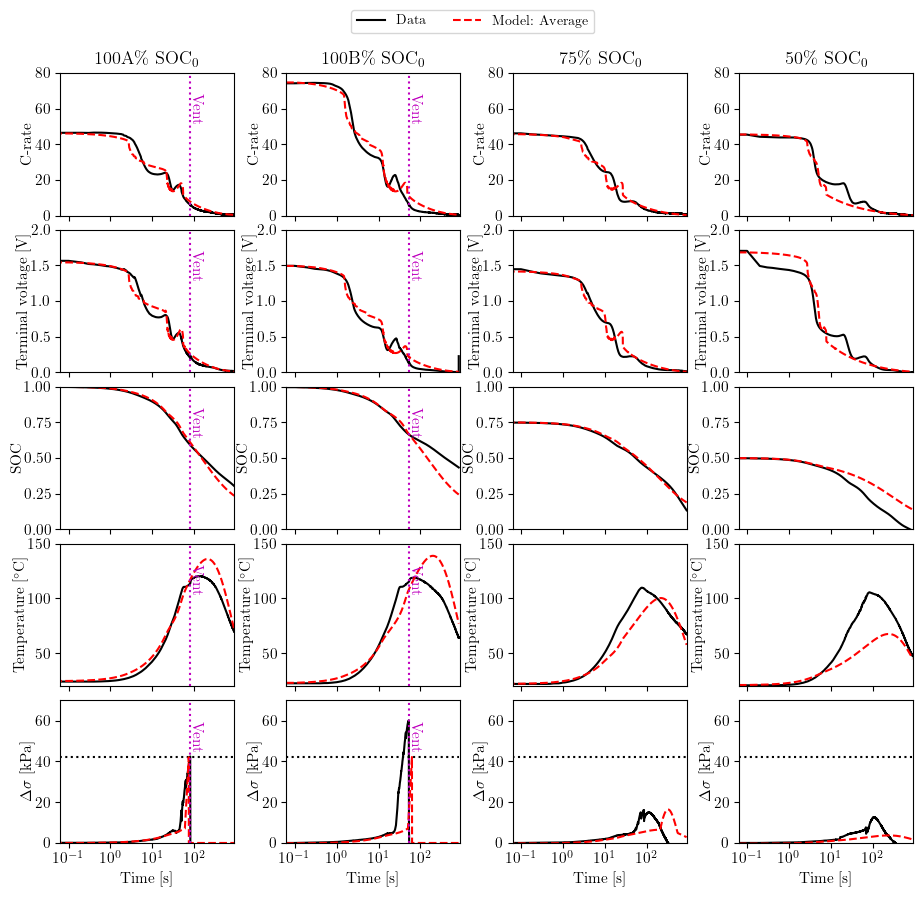

,SOC_names,e_I0,e_V0


In [ ]:
%matplotlib inline
param = pybamm.ParameterValues('Tran2023')
sim_set_labels = ['Model: Average', 'Model: Fit']
fig, ax = plt.subplots(5,  len(SOC_names), figsize=(11, 10), sharex=True, gridspec_kw = {'wspace':0.3, 'hspace':0.1}, constrained_layout=True)#, constrained_layout=True
# ax = ax.flatten()
linestyles = ['--',':','-.']*2
sim_colors = ['r','g','b','m']

t_refs = [1, 1*60, 5*60]
t_refs_labels = ['1 s', '1 min', '5 min']


# for each cell...
for k, solutions in enumerate([solutions_fit]): #, solutions_fit]): 
    e_I0 = []
    e_V0 = []
    SOC_names_list= []
    dSOCs_f = []
    dT_maxs = []
    dsigma_maxs = []
    rmses_I = []
    rmses_V = []
    rmses_T = []
    rmses_sigma = []
    dt_vents = []
    rmses_I_Tmax = []
    rmses_V_Tmax = []
    T_loss_eI = []

    for i, (solution, data) in enumerate(zip(solutions, datas)):    
        SOC_0 = SOC_0s[SOC_names[i]]

        # plot
        t = data.t
        x = solution["x [m]"].entries[:, 0]
        x_plot = t
        xlabel = "Time [s]"
        data_color = 'k'
        sim_color = sim_colors[k]
        sim_ls = linestyles[k]

        sigma_0 = data['F'].iloc[0]/param['Active material surface area [m2]']/1000,
        data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0

        if k ==0: 
            ax[0,i].semilogx(data.t,data.I/param['Nominal cell capacity [A.h]'], label='Data',color = data_color)
            ax[1,i].semilogx(data.t, data.V,color = data_color)
            ax[2,i].semilogx(data.t, data.SOC,color = data_color)
            ax[3,i].semilogx(data.t, data.Temp,color = data_color)
            ax[4,i].semilogx(data.t, data_sigma, color = data_color) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000

        I = solution['C-rate']
        e_I = I(t=data.t)  - data.I/param['Nominal cell capacity [A.h]'] 
        ax[0,i].semilogx(x_plot, I(t), linestyle=sim_ls, color = sim_color, label=sim_set_labels[k])
        # ax[0,i].plot(data.t,e_I, linestyle=':', label='_nolegend_',color = sim_color)
        # ax[0,i].set_xlabel(xlabel)
        ax[0,i].set_ylabel('C-rate', labelpad=0)
        ax[0,i].set_title(SOC_names[i] + "\% SOC$_0$") #, pad = 30
        ax[0,i].set_ylim([0,80])

        V = solution['Terminal voltage [V]']
        e_V = V(t=data.t)  - data.V 
        ax[1,i].semilogx(x_plot, V(t),linestyle=sim_ls, color = sim_color)
        # ax[1,i].set_xlabel(xlabel)
        ax[1,i].set_ylabel('Terminal voltage [V]', labelpad=0)
        ax[1,i].set_ylim([0,2])

        soc = SOC_0 - integrate.cumtrapz(I(t),t)/3600
        soc = np.insert(soc,0,SOC_0)
        ax[2,i].semilogx(x_plot, soc,linestyle=sim_ls, color = sim_color)  # can evaluate at arbitrary x (single representative particle)
        # ax[3,i].set_xlabel(xlabel)
        ax[2,i].set_ylabel('SOC',labelpad=0)
        ax[2,i].set_ylim([0,1])

        T = solution['Volume-averaged cell temperature [K]'](t) - 273.15
        ax[3,i].semilogx(x_plot, T,linestyle=sim_ls, color = sim_color)  
        # ax[2,i].set_xlabel(xlabel)
        ax[3,i].set_ylabel('Temperature [$^\circ$C]',labelpad=0)
        ax[3,i].set_ylim([20,150])
        e_T = T-data.Temp.iloc[0:len(T)]

        sigma_max = 42.35277961, #max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
        sigma = solution["Cell expansion stress [kPa]"](t)
        sigma_plot = sigma.copy()
        vent_check = np.argmax(sigma_plot>sigma_max)
        if vent_check > 0:
            sigma_plot[vent_check::] = 0  
            t_vent_sim = np.round(data.t[np.where(sigma_plot==0)[0][0]], 4)
            try: 
                t_vent_data = data.t.iloc[np.where(data_sigma == max(data_sigma))[0][0]]
                e_t_vent = t_vent_sim -  t_vent_data

            except: 
                t_vent_data = data.t.iloc[-1]
                e_t_vent = float('nan')
            print(e_t_vent)
        else: 
            t_vent_sim = np.round(data.t.iloc[-1],4)
            e_t_vent = float('nan')
        ax[4,i].semilogx([x_plot[0], x_plot.iloc[-1]], sigma_max*np.array([1,1]) , linestyle=':', color = data_color) #(out.P_est-P_atm)/1000-sigma_0/1000
        ax[4,i].semilogx(x_plot, sigma_plot,linestyle=sim_ls, color = sim_color)
        ax[4,i].set_ylim([0,70])
        ax[4,i].set_ylabel("$\Delta \sigma$ [kPa]",labelpad=0)
        ax[4,i].set_xlabel(xlabel)
        print(t_vent_sim)

        try:
            e_sigma = sigma_plot[np.round(t,4)<t_vent_sim]-  data_sigma[np.round(data.t,4)<t_vent_sim]
        except: 
            continue
        # for t_ref, t_ref_label in zip(t_refs, t_refs_labels):
        #     for j in range(0,5):
        #         ylims = ax[j,i].get_ylim()
        #         ax[j,i].semilogx([t_ref]*2, list(ylims), color = 'grey', linestyle = ':')
        #         if j ==0:
        #             ax[j,i].annotate(t_ref_label, xy=(t_ref, np.diff(ylims)*1+ ylims[0]), rotation=-45, color = 'grey', horizontalalignment = 'center', verticalalignment = 'bottom')
        #             ax[j,i].set_ylim(ylims) # keep original limits
        # for j in range(0,5):
            # ax[j,i].grid(True, axis='x')
        if SOC_0==1:# and (l == len(solutions)-1):
            for j in range(0,5):
                t_vent = data.t.iloc[0:-1][abs(np.diff(data['F'])) > 100].iloc[0]
                T_vent = data.Temp[abs(data.t-t_vent)<0.2].iloc[0]
                ylims = ax[j,i].get_ylim()
                ax[j,i].semilogx([t_vent]*2, list(ylims), color = 'm', linestyle = ':')
                ax[j,i].annotate('Vent', xy=(t_vent, np.diff(ylims)*0.85+ ylims[0]), rotation=-90, color = 'm', verticalalignment = 'top')
                ax[j,i].set_ylim(ylims) # keep original limits
        if k ==1:
            e_I0.append(e_I[1])
            e_V0.append(V(t=0) - data.V[1])
        
        # SAVE METRICS
        SOC_names_list.append(SOC_names[i])
        dSOCs_f.append(soc[-1] - data.SOC.iloc[-1])
        dT_maxs.append(max(T)-max(data.Temp))
        dsigma_maxs.append(max(sigma_plot) - max(data_sigma))
        try: 
            dt_vents.append(e_t_vent)
        except:
            dt_vents.append('-')

        rmses_I.append(np.sqrt(np.mean(np.square(e_I))))
        rmses_V.append(np.sqrt(np.mean(np.square(e_V))))
        rmses_I_Tmax.append(np.sqrt(np.mean(np.square(e_I[0:np.where(data.Temp==max(data.Temp))[0][0]]))))
        rmses_V_Tmax.append(np.sqrt(np.mean(np.square(e_V[0:np.where(data.Temp==max(data.Temp))[0][0]]))))
        rmses_T.append(np.sqrt(np.mean(np.square(e_T))))
        rmses_sigma.append(np.sqrt(np.mean(np.square(e_sigma))))
        idx_T_max = np.where(data.Temp==max(data.Temp))[0][0]
        Q_loss_T_max = np.trapz(I(t=data.t[0:idx_T_max])*param['Nominal cell capacity [A.h]']*(-V(t=data.t[0:idx_T_max])+ocv(soc[0:idx_T_max])),data.t[0:idx_T_max])
        T_loss_eI.append(Q_loss_T_max)
    
    df = pd.DataFrame(list(zip(SOC_names_list,dSOCs_f , dT_maxs, dsigma_maxs, dt_vents, rmses_I, rmses_I_Tmax, rmses_V_Tmax, rmses_V, rmses_T,rmses_sigma,T_loss_eI)),
               columns =['SOC_names','dSOCs_f' , 'dT_maxs', 'dsigma_maxs', 'dt_vents', 'rmses_I','rmses_I_Tmax','rmses_V_Tmax', 'rmses_V', 'rmses_T','rmses_sigma','T_loss_eI'])
    display(round(df,2))


# for axs in fig.get_axes():
#     axs.grid()

plt.setp(ax, xticks=[1e-1, 1,10,100, 1000])
handles, labels = ax[0,0].get_legend_handles_labels()
## fig.legend(handles, labels, loc='upper center', ncol=3, prop={'size': 10},  bbox_to_anchor=(0.5, 1), fancybox=True)
fig.legend(handles, labels, loc='upper center', ncol=3, prop={'size': 10},  bbox_to_anchor=(0.5, 0.95))
plt.xlim([0,t_end])
plt.tight_layout()
plt.savefig('./figs/all_ESC_combined_log_avg_vs_fit.eps', format='eps', dpi = 300)
# plt.savefig('./figs/all_ESC_combined_log_avg.jpg', format='jpg', dpi = 300,bbox_inches='tight')
plt.show()

df = pd.DataFrame(list(zip(SOC_names, e_I0, e_V0)), columns=['SOC_names', 'e_I0', 'e_V0'])
display(df)




## Linear time

2024-01-22 17:21:50.503 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-01-22 17:21:50.503 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')


-26.0


ValueError: operands could not be broadcast together with shapes (9000,) (8186,) 

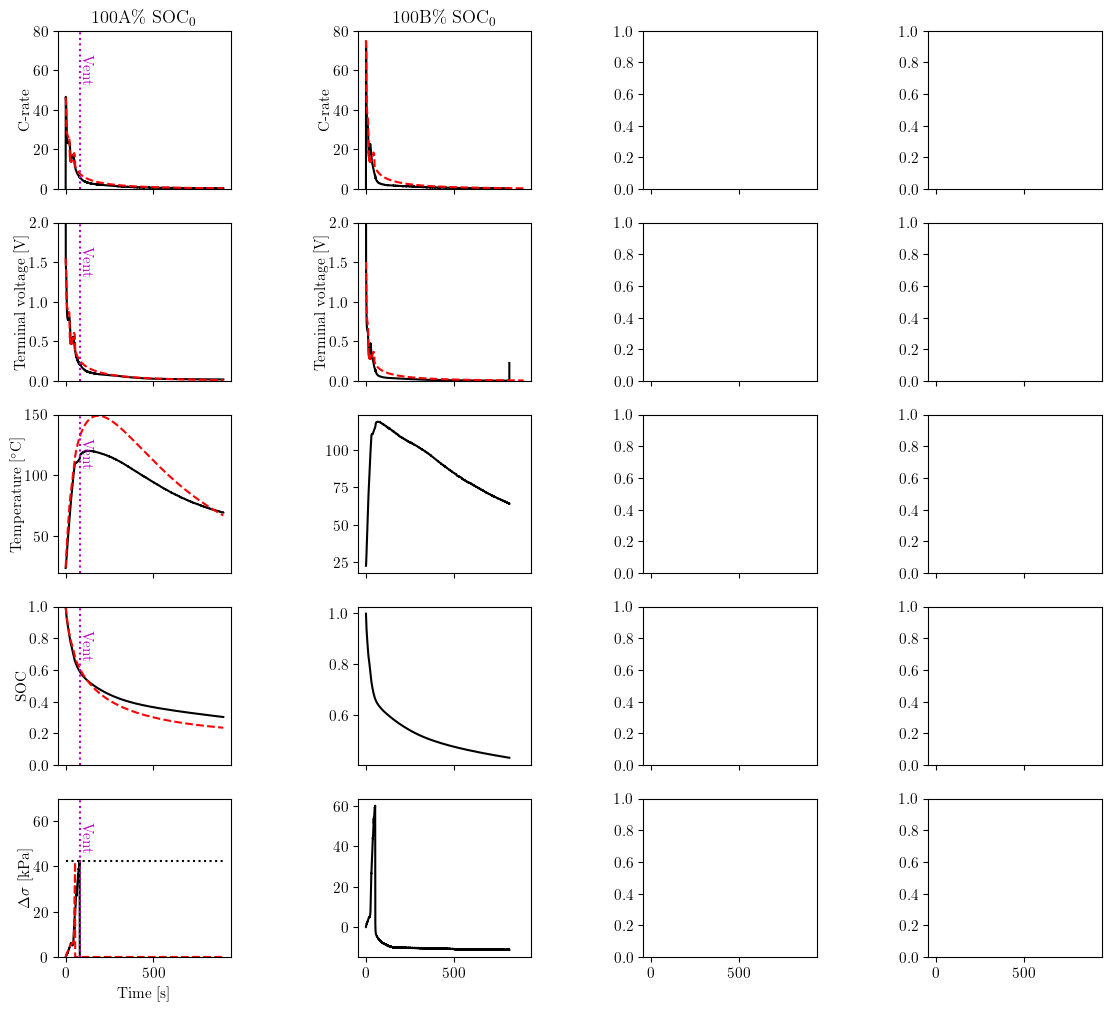

No such comm: 73e110054f7b463ba57e0a2de824af1c


2024-01-23 14:06:26.290 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-01-23 14:06:26.301 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')


-26.0


ValueError: operands could not be broadcast together with shapes (9000,) (8186,) 

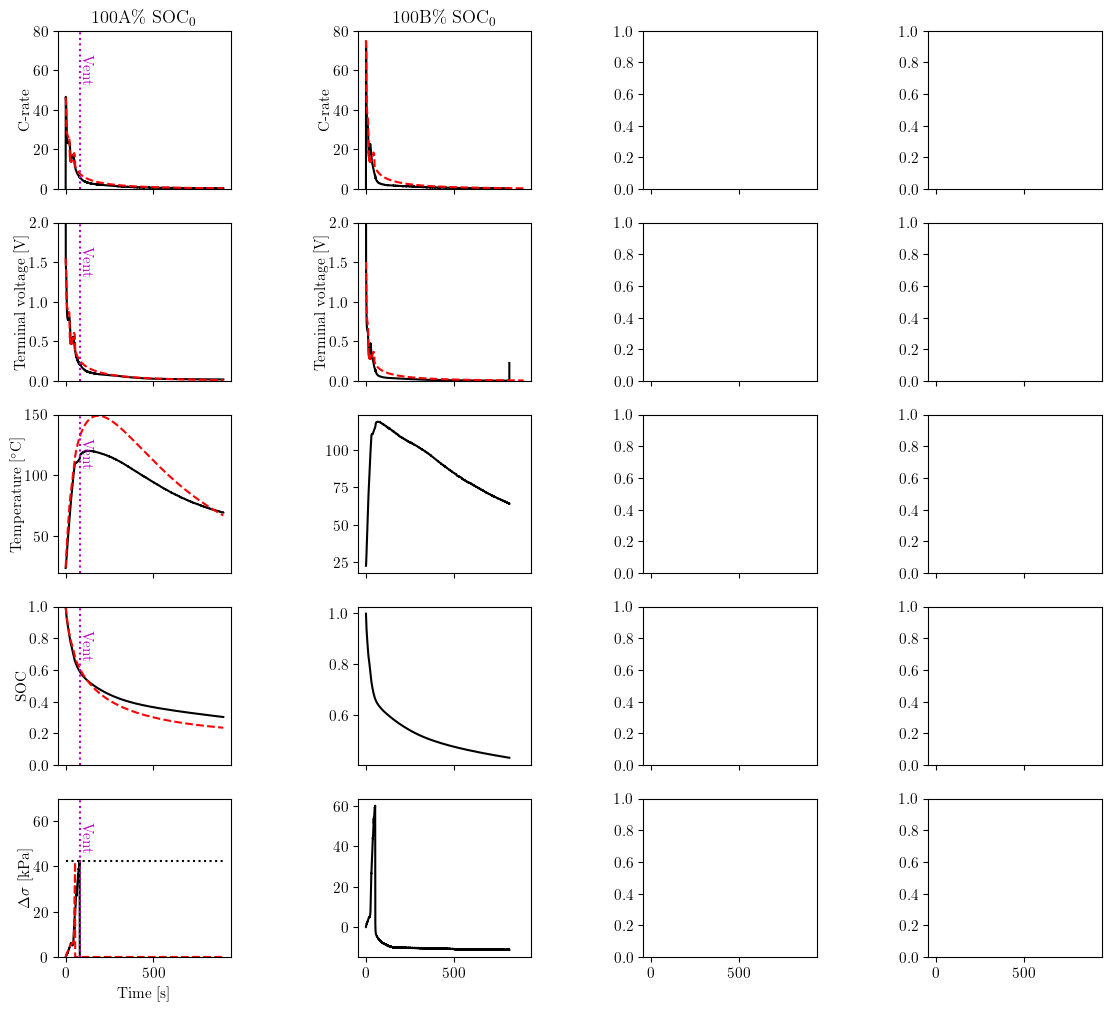

In [ ]:
%matplotlib inline
param = pybamm.ParameterValues('Tran2023')
sim_set_labels = ['Model: Average', 'Model: Fit']
fig, ax = plt.subplots(5,  len(SOC_names), figsize=(11, 10), sharex=True, gridspec_kw = {'wspace':0.3, 'hspace':0.1}, constrained_layout=True)#, constrained_layout=True
# ax = ax.flatten()
linestyles = ['--',':','-.']*2
sim_colors = ['r','g','b','m']

t_refs = [1, 1*60, 5*60]
t_refs_labels = ['1 s', '1 min', '5 min']

SOC_names_list = []
dSOCs_f = []
dT_maxs = []
dsigma_maxs = []
rmses_I = []
rmses_V = []
rmses_T = []
rmses_sigma = []
dt_vents = []

# for each cell...
for k, solutions in enumerate([solutions_avg]): 
    for i, (solution, data) in enumerate(zip(solutions, datas)):    
        SOC_0 = SOC_0s[SOC_names[i]]

        # plot
        t = solution["Time [s]"].entries
        x = solution["x [m]"].entries[:, 0]
        x_plot = t
        xlabel = "Time [s]"
        data_color = 'k'
        sim_color = sim_colors[k]
        sim_ls = '--'

        sigma_0 = data['F'].iloc[0]/param['Active material surface area [m2]']/1000,
        data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0

        if k ==0: 
            ax[0,i].plot(data.t,data.I/param['Nominal cell capacity [A.h]'], label='Data',color = data_color)
            ax[1,i].plot(data.t, data.V,color = data_color)
            ax[2,i].plot(data.t, data.Temp,color = data_color)
            ax[3,i].plot(data.t, data.SOC,color = data_color)
            ax[4,i].plot(data.t, data_sigma, color = data_color) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000

        I = solution['C-rate']
        e_I = I(t=data.t)  - data.I/param['Nominal cell capacity [A.h]'] 
        ax[0,i].plot(x_plot, I(t), linestyle='--', color = sim_color, label=sim_set_labels[k])
        # ax[0,i].plot(data.t,e_I, linestyle=':', label='_nolegend_',color = sim_color)
        # ax[0,i].set_xlabel(xlabel)
        ax[0,i].set_ylabel('C-rate', labelpad=0)
        ax[0,i].set_title(SOC_names[i] + "\% SOC$_0$") #, pad = 30
        ax[0,i].set_ylim([0,80])

        V = solution['Terminal voltage [V]']
        e_V = V(t=data.t)  - data.V 
        ax[1,i].plot(x_plot, V(t),linestyle=sim_ls, color = sim_color)
        # ax[1,i].set_xlabel(xlabel)
        ax[1,i].set_ylabel('Terminal voltage [V]', labelpad=0)
        ax[1,i].set_ylim([0,2])

        T = solution['Volume-averaged cell temperature [K]'].entries - 273.15
        e_T = T-data.Temp.iloc[0:len(T)]
        ax[2,i].plot(x_plot, T,linestyle=sim_ls, color = sim_color)  
        # ax[2,i].set_xlabel(xlabel)
        ax[2,i].set_ylabel('Temperature [$^\circ$C]',labelpad=0)
        ax[2,i].set_ylim([20,150])

        soc = SOC_0 - integrate.cumtrapz(I(t),t)/3600
        soc = np.insert(soc,0,SOC_0)
        ax[3,i].plot(x_plot, soc,linestyle='--', color = sim_color)  # can evaluate at arbitrary x (single representative particle)
        # ax[3,i].plot(data.t, e_soc,linestyle=':', color = sim_color)  # can evaluate at arbitrary x (single representative particle)
        # ax[3,i].set_xlabel(xlabel)
        ax[3,i].set_ylabel('SOC',labelpad=0)
        ax[3,i].set_ylim([0,1])

        # sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
        sigma_max = 42.35277961, #max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell

        sigma = solution["Cell expansion stress [kPa]"].entries
        sigma_plot = sigma.copy()
        vent_check = np.argmax(sigma_plot>sigma_max)
        if vent_check > 0:
            sigma_plot[vent_check::] = 0  
            t_vent_sim = data.t[np.where(sigma_plot==0)[0][0]]
            try: 
                t_vent_data = data.t.iloc[np.where(data_sigma == max(data_sigma))[0][0]]
                e_t_vent = t_vent_sim -  t_vent_data

            except: 
                t_vent_data = data.t.iloc[-1]
                e_t_vent = float('nan')
            print(e_t_vent)
        ax[4,i].plot([x_plot[0], x_plot[-1]], sigma_max*np.array([1,1]) , linestyle=':', color = data_color) #(out.P_est-P_atm)/1000-sigma_0/1000
        ax[4,i].plot(x_plot, sigma_plot,linestyle=sim_ls, color = sim_color)
        ax[4,i].set_ylim([0,70])
        ax[4,i].set_ylabel("$\Delta \sigma$ [kPa]",labelpad=0)
        ax[4,i].set_xlabel(xlabel)
        # e_sigma = sigma_plot[t<t_vent_data] -  data_sigma[data.t<t_vent_data]


        # for t_ref, t_ref_label in zip(t_refs, t_refs_labels):
        #     for j in range(0,5):
        #         ylims = ax[j,i].get_ylim()
        #         ax[j,i].semilogx([t_ref]*2, list(ylims), color = 'grey', linestyle = ':')
        #         if j ==0:
        #             ax[j,i].annotate(t_ref_label, xy=(t_ref, np.diff(ylims)*1+ ylims[0]), rotation=-45, color = 'grey', horizontalalignment = 'center', verticalalignment = 'bottom')
        #             ax[j,i].set_ylim(ylims) # keep original limits
        # for j in range(0,5):
            # ax[j,i].grid(True, axis='x')
        if SOC_0==1:# and (l == len(solutions)-1):
            for j in range(0,5):
                t_vent = data.t.iloc[0:-1][abs(np.diff(data['F'])) > 100].iloc[0]
                T_vent = data.Temp[abs(data.t-t_vent)<0.2].iloc[0]
                ylims = ax[j,i].get_ylim()
                ax[j,i].plot([t_vent]*2, list(ylims), color = 'm', linestyle = ':')
                ax[j,i].annotate('Vent', xy=(t_vent, np.diff(ylims)*0.85+ ylims[0]), rotation=-90, color = 'm', verticalalignment = 'top')
                ax[j,i].set_ylim(ylims) # keep original limits

        
        # SAVE METRICS
        SOC_names_list.append(SOC_names[i])
        dSOCs_f.append(soc[-1] - data.SOC.iloc[-1])
        dT_maxs.append(max(T)-max(data.Temp))
        dsigma_maxs.append(max(sigma_plot) - max(data_sigma))
        try: 
            dt_vents.append(e_t_vent)
        except:
            dt_vents.append('-')

        rmses_I.append(np.sqrt(np.mean(np.square(e_I))))
        rmses_V.append(np.sqrt(np.mean(np.square(e_V))))
        rmses_T.append(np.sqrt(np.mean(np.square(e_T))))
        # rmses_sigma.append(np.sqrt(np.mean(np.square(e_sigma))))

# plt.setp(ax, xticks=[1e-1, 1,10,100, 1000])
handles, labels = ax[0,0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper center', ncol=3, prop={'size': 10},  bbox_to_anchor=(0.5, 1), fancybox=True)
fig.legend(handles, labels, loc='upper center', ncol=3, prop={'size': 10},  bbox_to_anchor=(0.5, 0.95))
plt.xlim([0,300])
plt.tight_layout()
# plt.savefig('./figs/all_ESC_combined_linear_avg_vs_fit.eps', format='eps', dpi = 300)
plt.show()

# df = pd.DataFrame(list(zip(SOC_names_list,dSOCs_f , dT_maxs, dsigma_maxs, dt_vents, rmses_I, rmses_V, rmses_T,rmses_sigma)),
#                columns =['SOC_names','dSOCs_f' , 'dT_maxs', 'dsigma_maxs', 'dt_vents', 'rmses_I', 'rmses_V', 'rmses_T','rmses_sigma'])
# display(round(df,2))


# PLOT: Heat contribution 

In [ ]:
chemistry = pybamm.parameter_sets.Tran2023
param = pybamm.ParameterValues(chemistry)
T_amb_0 = datas[0].Temp[0]

param.update({
    "Ambient temperature [K]":T_amb_0 + 273.15,
    "Initial temperature [K]": T_amb_0 + 273.15,
    "Negative tab width [m]":2.5e-2,
    "Positive tab width [m]":2.5e-2,
    # "Edge heat transfer coefficient [W.m-2.K-1]":h,
    "Total heat transfer coefficient [W.m-2.K-1]":hs['100A'],
    "Negative electrode specific heat capacity [J.kg-1.K-1]": 1100*Cps['100A'],
    "Positive electrode specific heat capacity [J.kg-1.K-1]": 1100*Cps['100A'],
    "Cell open circuit voltage [V]": ocv,
    "Cell capacity [A.h]": 4.6, #nominal
    "Typical current [A]": 4.6,
    "Negative electrode thickness [m]":62E-06*4.2/5,
    "Positive electrode thickness [m]":67E-06*4.2/5,
}, check_already_exists = False)
liion = pybamm.LithiumIonParameters()
Q_scale = param.evaluate(liion.i_typ) * param.evaluate(liion.potential_scale) / param.evaluate(liion.L_x)
C_th = param.evaluate(liion.tau_th_yz)/param.evaluate(liion.tau_discharge) # self.tau_th_yz / self.timescale
L_x = param.evaluate(pybamm.geometric_parameters.L_x)
L_xn = param.evaluate(pybamm.geometric_parameters.n.L)
L_y = param.evaluate(pybamm.geometric_parameters.L_y)
L_z = param.evaluate(pybamm.geometric_parameters.L_z)
L = param.evaluate(pybamm.geometric_parameters.L)
V_cell = L*L_y*L_z

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


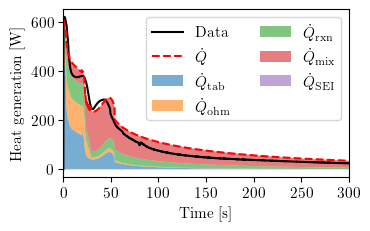

In [ ]:
%matplotlib inline

solution = solutions_avg[0]
data = load_data(1, '100A')[0]
# vars to plot
Qs = [
    'Tab heating [W.m-3]',
    'Volume-averaged Ohmic heating [W.m-3]',
    'Volume-averaged irreversible electrochemical heating [W.m-3]',
    'Volume-averaged heat of mixing [W.m-3]',
    'SEI decomposition heating [W.m-3]',
]
labels = [
    '$\dot{Q}_\mathrm{{tab}}$',
    '$\dot{Q}_\mathrm{{ohm}}$',
    '$\dot{Q}_\mathrm{{rxn}}$',
    '$\dot{Q}_\mathrm{{mix}}$',
    '$\dot{Q}_\mathrm{{SEI}}$',
]

# plot total 
t = solution['Time [s]'].entries
xlabel = "Time [s]"
fig, ax = plt.subplots(1,  1, figsize=(4, 2.5), sharex=True, constrained_layout=True)#, constrained_layout=True
sim_colors = ['r', 'b', 'limegreen','darkorange', 'm']


Q_total = (solution['Volume-averaged total heating [W.m-3]'].entries)*V_cell
ax.plot(data.t, data.I*(ocv(data.SOC)-data.V), color = 'k', label = "Data")# (RMSE = " + str(np.round(rmse_T_pybamm, 1)) + '$^\circ$C)')
ax.plot(t, Q_total, color = 'r', linestyle = '--', label = '$\dot{Q}$') #$_\mathrm{{total}}$

bottom = [0]*len(t)
for i, (Q,label) in enumerate(zip(Qs, labels)): 
    top = bottom + solution[Q](t)*V_cell
    ax.fill_between(t, bottom, top, alpha = 0.6, label=label)
    bottom = top
    
ax.set_xlim(0,300)
ax.set_xlabel(xlabel)
ax.set_ylabel('Heat generation [W]')
# handles, labels = ax.get_legend_handles_labels()
plt.legend(loc = 'upper right', ncol=2)
plt.savefig('./figs/heat_component.eps', format='eps', dpi = 300)
plt.tight_layout()
plt.show()

# Archive

NameError: name 'solutions_iso' is not defined

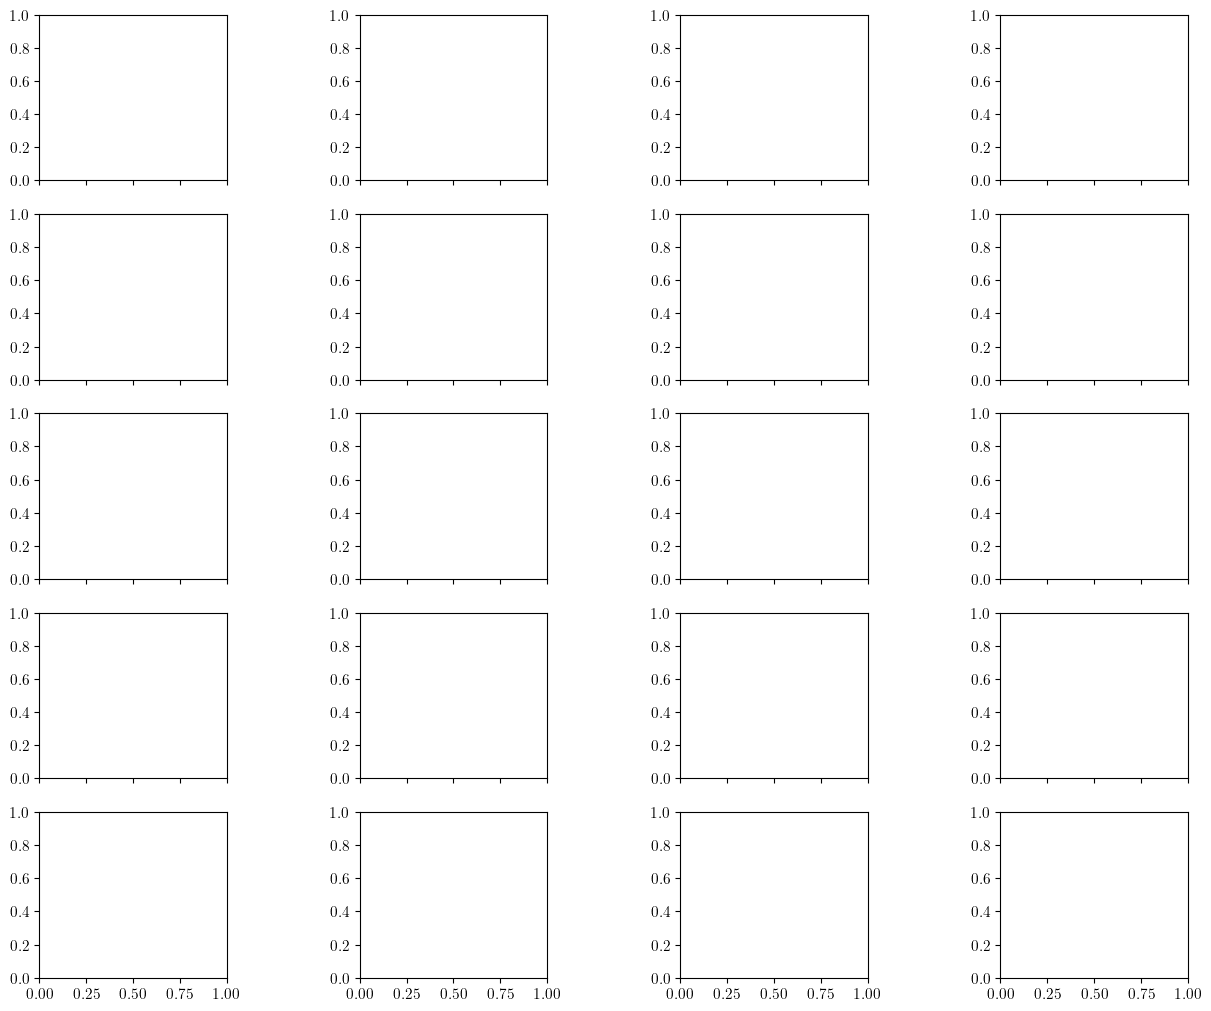

No such comm: e3e6b94057c846038aabca6bfa65e2ff


NameError: name 'solutions_iso' is not defined

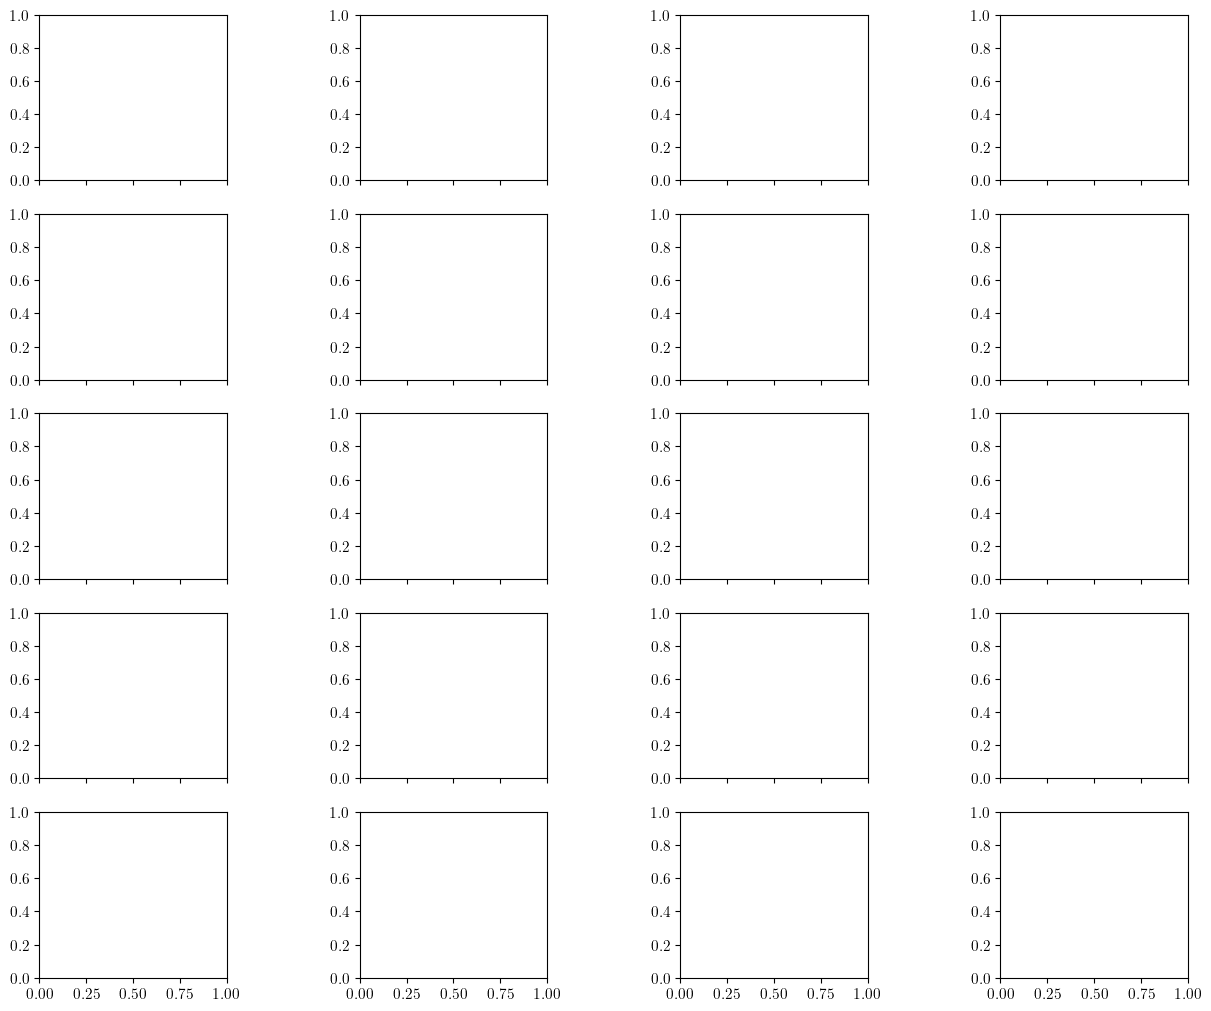

In [ ]:
param = pybamm.ParameterValues('Tran2023')

fig, ax = plt.subplots(5,  len(SOC_names), figsize=(12, 10), sharex=True, gridspec_kw = {'wspace':0.3, 'hspace':0.1}, constrained_layout=True)#, constrained_layout=True
# ax = ax.flatten()
linestyles = ['--',':','-.']*2
sim_colors = ['r','g','b','m']

# for each cell...
for i, (solution,data) in enumerate(zip(solutions_iso, datas)):    
    SOC_0 = SOC_0s[SOC_names[i]]

    # plot
    t = solution["Time [s]"].entries
    x = solution["x [m]"].entries[:, 0]
    x_plot = t
    xlabel = "Time [s]"
    data_color = 'k'
    sim_color = 'r' #sim_colors[i]
    sim_ls = '--'

    I = solution['C-rate']
    e_I = I(t=data.t)  - data.I/param['Nominal cell capacity [A.h]'] 
    ax[0,i].plot(data.t,data.I/param['Nominal cell capacity [A.h]'], label='Data',color = data_color)
    ax[0,i].plot(x_plot, I(t), linestyle='--', color = sim_color, label='Model')
    # ax[0,i].plot(data.t,e_I, linestyle=':', label='_nolegend_',color = sim_color)
    # ax[0,i].set_xlabel(xlabel)
    ax[0,i].set_ylabel('C-rate', labelpad=0)
    ax[0,i].set_title(SOC_names[i] + "\% SOC$_0$")
    ax[0,i].set_ylim([0,80])

    V = solution['Terminal voltage [V]']
    ax[1,i].plot(data.t, data.V,color = data_color)
    ax[1,i].plot(x_plot, V(t),linestyle=sim_ls, color = sim_color)
    # ax[1,i].set_xlabel(xlabel)
    ax[1,i].set_ylabel('Terminal voltage [V]')
    ax[1,i].set_ylim([0,2])

    T = solution['Volume-averaged cell temperature [K]'].entries - 273.15
    ax[2,i].plot(data.t, data.Temp,color = data_color)
    ax[2,i].plot(x_plot, T,linestyle=sim_ls, color = sim_color)  
    # ax[2,i].set_xlabel(xlabel)
    ax[2,i].set_ylabel('Temperature [$^\circ$C]',labelpad=0)
    ax[2,i].set_ylim([0,150])

    soc = SOC_0 - integrate.cumtrapz(I(t),t)/3600
    soc = np.insert(soc,0,SOC_0)
    ax[3,i].plot(data.t, data.SOC,color = data_color)
    ax[3,i].plot(x_plot, soc,linestyle='--', color = sim_color)  # can evaluate at arbitrary x (single representative particle)
    # ax[3,i].plot(data.t, e_soc,linestyle=':', color = sim_color)  # can evaluate at arbitrary x (single representative particle)
    # ax[3,i].set_xlabel(xlabel)
    ax[3,i].set_ylabel('SOC',labelpad=0)
    ax[3,i].set_ylim([0,1])

    sigma_0 = data['F'].iloc[0]/param['Active material surface area [m2]']/1000,
    data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0
    sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
    sigma = solution["Cell expansion stress [kPa]"].entries
    sigma_plot = sigma.copy()
    vent_check = np.argmax(sigma_plot>sigma_max)
    if vent_check > 0:
        sigma_plot[vent_check::] = 0  
    ax[4,i].plot(data.t, data_sigma, color = data_color) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000
    ax[4,i].plot([x_plot[0], x_plot[-1]], sigma_max*np.array([1,1]) , linestyle=':', color = data_color) #(out.P_est-P_atm)/1000-sigma_0/1000
    ax[4,i].plot(x_plot, sigma_plot,linestyle=sim_ls, color = sim_color)
    ax[4,i].set_ylim([0,70])
    ax[4,i].set_ylabel("$\Delta \sigma$ [kPa]",labelpad=0)
    ax[4,i].set_xlabel(xlabel)

    if SOC_0==1:# and (l == len(solutions)-1):
        for j in range(0,5):
            t_vent = data.t.iloc[0:-1][abs(np.diff(data['F'])) > 100].iloc[0]
            T_vent = data.Temp[abs(data.t-t_vent)<0.2].iloc[0]
            ylims = ax[j,i].get_ylim()
            ax[j,i].plot([t_vent]*2, list(ylims), color = 'm', linestyle = ':')
            ax[j,i].annotate('Venting', xy=(t_vent, np.diff(ylims)*0.5+ ylims[0]), rotation=-90, color = 'm')
            ax[j,i].set_ylim(ylims) # keep original limits


handles, labels = ax[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, prop={'size': 10},  bbox_to_anchor=(0.5, .95), fancybox=True)
plt.xlim([0,t_end])
plt.tight_layout()
# plt.savefig('./figs/all_ESC_combined_linear.eps', format='eps', dpi = 300)
plt.show()


2023-10-15 03:06:59.344 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2023-10-15 03:06:59.374 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2023-10-15 03:06:59.404 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2023-10-15 03:06:59.422 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


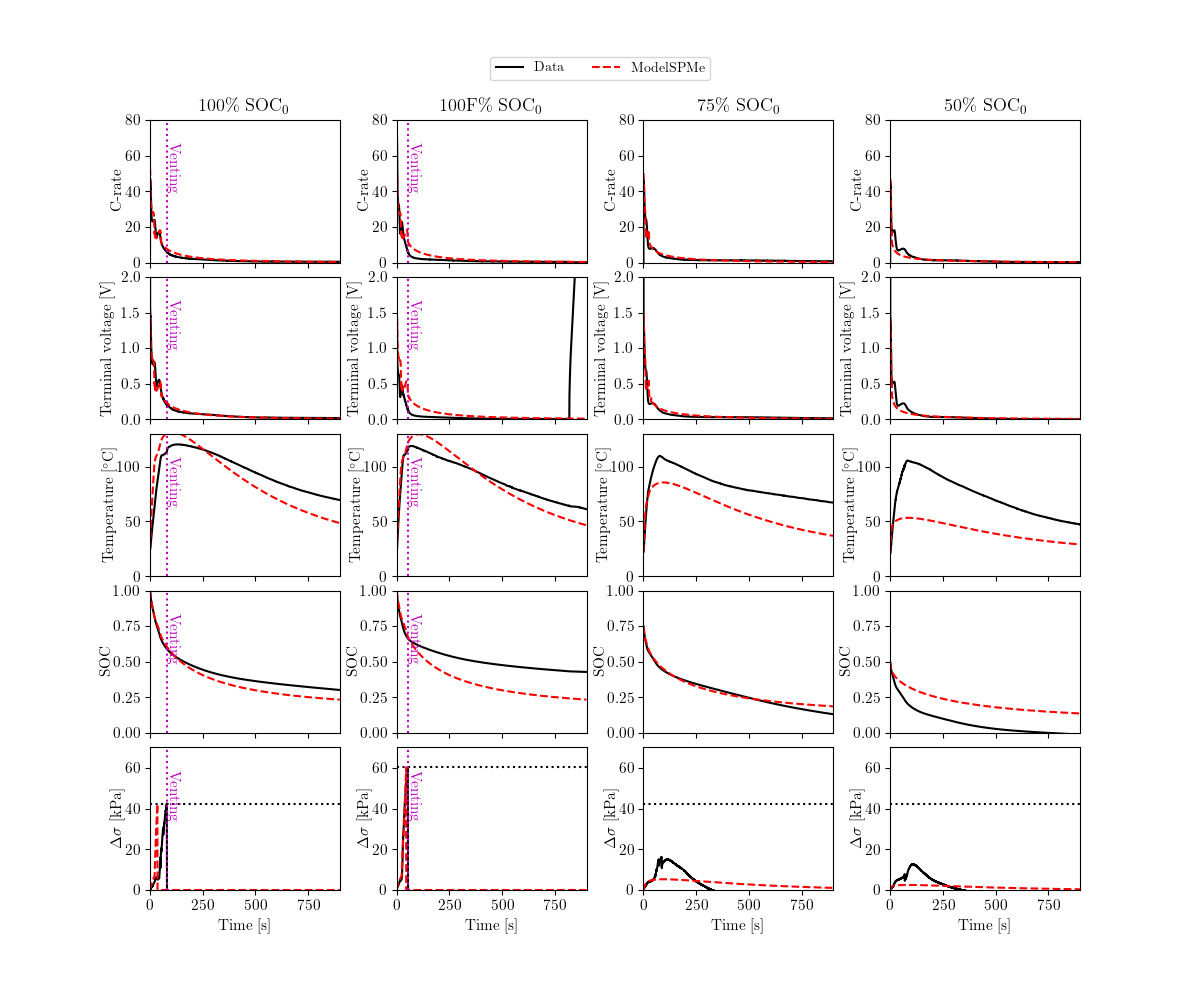

In [ ]:
param = pybamm.ParameterValues('Tran2023')
sim_set_labels = ['SPMe', 'SPMeT']
fig, ax = plt.subplots(5,  len(SOC_names), figsize=(12, 10), sharex=True, gridspec_kw = {'wspace':0.3, 'hspace':0.1}, constrained_layout=True)#, constrained_layout=True
# ax = ax.flatten()
linestyles = ['--',':','-.']*2
sim_colors = ['r','g','b','m']

# for each cell...
for k, solutions in enumerate([solutions_iso, solutions_therm]): 
    for i, (solution, data) in enumerate(zip(solutions, datas)):    
        SOC_0 = SOC_0s[SOC_names[i]]

        # plot
        t = solution["Time [s]"].entries
        x = solution["x [m]"].entries[:, 0]
        x_plot = t
        xlabel = "Time [s]"
        data_color = 'k'
        sim_color = sim_colors[k]
        sim_ls = '--'

        sigma_0 = data['F'].iloc[0]/param['Active material surface area [m2]']/1000,
        data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0

        if k ==0: 
            ax[0,i].plot(data.t,data.I/param['Nominal cell capacity [A.h]'], label='Data',color = data_color)
            ax[1,i].plot(data.t, data.V,color = data_color)
            ax[2,i].plot(data.t, data.Temp,color = data_color)
            ax[3,i].plot(data.t, data.SOC,color = data_color)
            ax[4,i].plot(data.t, data_sigma, color = data_color) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000

        I = solution['C-rate']
        e_I = I(t=data.t)  - data.I/param['Nominal cell capacity [A.h]'] 
        ax[0,i].plot(x_plot, I(t), linestyle='--', color = sim_color, label='Model' + sim_set_labels[k])
        # ax[0,i].plot(data.t,e_I, linestyle=':', label='_nolegend_',color = sim_color)
        # ax[0,i].set_xlabel(xlabel)
        ax[0,i].set_ylabel('C-rate', labelpad=0)
        ax[0,i].set_title(SOC_names[i] + "\% SOC$_0$")
        ax[0,i].set_ylim([0,80])

        V = solution['Terminal voltage [V]']
        ax[1,i].plot(x_plot, V(t),linestyle=sim_ls, color = sim_color)
        # ax[1,i].set_xlabel(xlabel)
        ax[1,i].set_ylabel('Terminal voltage [V]')
        ax[1,i].set_ylim([0,2])

        T = solution['Volume-averaged cell temperature [K]'].entries - 273.15
        ax[2,i].plot(x_plot, T,linestyle=sim_ls, color = sim_color)  
        # ax[2,i].set_xlabel(xlabel)
        ax[2,i].set_ylabel('Temperature [$^\circ$C]',labelpad=0)
        ax[2,i].set_ylim([0,130])

        soc = SOC_0 - integrate.cumtrapz(I(t),t)/3600
        soc = np.insert(soc,0,SOC_0)
        ax[3,i].plot(x_plot, soc,linestyle='--', color = sim_color)  # can evaluate at arbitrary x (single representative particle)
        # ax[3,i].plot(data.t, e_soc,linestyle=':', color = sim_color)  # can evaluate at arbitrary x (single representative particle)
        # ax[3,i].set_xlabel(xlabel)
        ax[3,i].set_ylabel('SOC',labelpad=0)
        ax[3,i].set_ylim([0,1])

        sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
        sigma = solution["Cell expansion stress [kPa]"].entries
        sigma_plot = sigma.copy()
        vent_check = np.argmax(sigma_plot>sigma_max)
        if vent_check > 0:
            sigma_plot[vent_check::] = 0  
        ax[4,i].plot([x_plot[0], x_plot[-1]], sigma_max*np.array([1,1]) , linestyle=':', color = data_color) #(out.P_est-P_atm)/1000-sigma_0/1000
        ax[4,i].plot(x_plot, sigma_plot,linestyle=sim_ls, color = sim_color)
        ax[4,i].set_ylim([0,70])
        ax[4,i].set_ylabel("$\Delta \sigma$ [kPa]",labelpad=0)
        ax[4,i].set_xlabel(xlabel)

        if SOC_0==1:# and (l == len(solutions)-1):
            for j in range(0,5):
                t_vent = data.t.iloc[0:-1][abs(np.diff(data['F'])) > 100].iloc[0]
                T_vent = data.Temp[abs(data.t-t_vent)<0.2].iloc[0]
                ylims = ax[j,i].get_ylim()
                ax[j,i].plot([t_vent]*2, list(ylims), color = 'm', linestyle = ':')
                ax[j,i].annotate('Venting', xy=(t_vent, np.diff(ylims)*0.5+ ylims[0]), rotation=-90, color = 'm')
                ax[j,i].set_ylim(ylims) # keep original limits


handles, labels = ax[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, prop={'size': 10},  bbox_to_anchor=(0.5, .95), fancybox=True)
plt.xlim([0,t_end])
plt.tight_layout()
plt.savefig('./figs/all_ESC_combined_linear_therm_vs_iso.eps', format='eps', dpi = 300)
plt.show()


2023-10-15 02:48:06.549 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2023-10-15 02:48:06.585 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2023-10-15 02:48:06.617 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2023-10-15 02:48:06.639 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


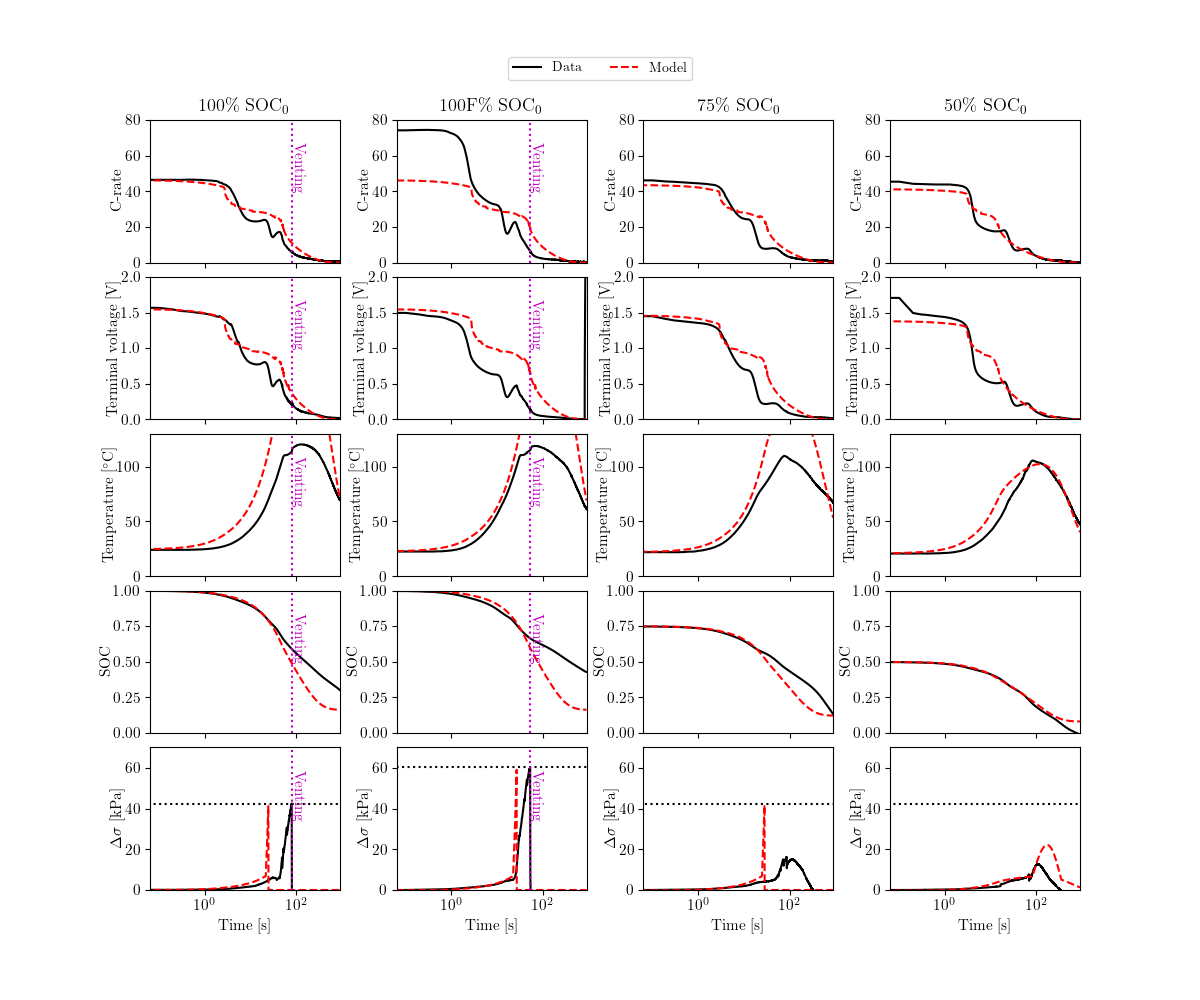

In [ ]:
param = pybamm.ParameterValues('Tran2023')

fig, ax = plt.subplots(5,  len(SOC_names), figsize=(12, 10), sharex=True, gridspec_kw = {'wspace':0.3, 'hspace':0.1}, constrained_layout=True)#, constrained_layout=True
# ax = ax.flatten()
linestyles = ['--',':','-.']*2
sim_colors = ['r','g','b','m']

# for each cell...
for i, (solution,data) in enumerate(zip(solutions, datas)):    
    SOC_0 = SOC_0s[SOC_names[i]]

    # plot
    t = solution["Time [s]"].entries
    x = solution["x [m]"].entries[:, 0]
    x_plot = t
    xlabel = "Time [s]"
    data_color = 'k'
    sim_color = 'r' #sim_colors[i]
    sim_ls = '--'

    I = solution['C-rate']
    e_I = I(t=data.t)  - data.I/param['Nominal cell capacity [A.h]'] 
    ax[0,i].semilogx(data.t,data.I/param['Nominal cell capacity [A.h]'], label='Data',color = data_color)
    ax[0,i].semilogx(x_plot, I(t), linestyle='--', color = sim_color, label='Model')
    # ax[0,i].plot(data.t,e_I, linestyle=':', label='_nolegend_',color = sim_color)
    # ax[0,i].set_xlabel(xlabel)
    ax[0,i].set_ylabel('C-rate', labelpad=0)
    ax[0,i].set_title(SOC_names[i] + "\% SOC$_0$")
    ax[0,i].set_ylim([0,80])

    V = solution['Terminal voltage [V]']
    ax[1,i].semilogx(data.t, data.V,color = data_color)
    ax[1,i].semilogx(x_plot, V(t),linestyle=sim_ls, color = sim_color)
    # ax[1,i].set_xlabel(xlabel)
    ax[1,i].set_ylabel('Terminal voltage [V]',labelpad=0)
    ax[1,i].set_ylim([0,2])

    T = solution['Volume-averaged cell temperature [K]'].entries - 273.15
    ax[2,i].semilogx(data.t, data.Temp,color = data_color)
    ax[2,i].semilogx(x_plot, T,linestyle=sim_ls, color = sim_color)  
    # ax[2,i].set_xlabel(xlabel)
    ax[2,i].set_ylabel('Temperature [$^\circ$C]',labelpad=0)
    ax[2,i].set_ylim([0,130])

    soc = SOC_0 - integrate.cumtrapz(I(t),t)/3600
    soc = np.insert(soc,0,SOC_0)
    ax[3,i].semilogx(data.t, data.SOC,color = data_color)
    ax[3,i].semilogx(x_plot, soc,linestyle='--', color = sim_color)  # can evaluate at arbitrary x (single representative particle)
    # ax[3,i].plot(data.t, e_soc,linestyle=':', color = sim_color)  # can evaluate at arbitrary x (single representative particle)
    # ax[3,i].set_xlabel(xlabel)
    ax[3,i].set_ylabel('SOC',labelpad=0)
    ax[3,i].set_ylim([0,1])

    sigma_0 = data['F'].iloc[0]/param['Active material surface area [m2]']/1000,
    data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0
    sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
    sigma = solution["Cell expansion stress [kPa]"].entries
    sigma_plot = sigma.copy()
    vent_check = np.argmax(sigma_plot>sigma_max)
    if vent_check > 0:
        sigma_plot[vent_check::] = 0  
    ax[4,i].semilogx(data.t, data_sigma, color = data_color) #data.Force(data_idx)/A_surf/1000 -sigma_0/1000
    ax[4,i].semilogx([x_plot[0], x_plot[-1]], sigma_max*np.array([1,1]) , linestyle=':', color = data_color) #(out.P_est-P_atm)/1000-sigma_0/1000
    ax[4,i].semilogx(x_plot, sigma_plot,linestyle=sim_ls, color = sim_color)
    ax[4,i].set_ylim([0,70])
    ax[4,i].set_ylabel("$\Delta \sigma$ [kPa]",labelpad=0)
    ax[4,i].set_xlabel(xlabel)

    if SOC_0==1:# and (l == len(solutions)-1):
        for j in range(0,5):
            t_vent = data.t.iloc[0:-1][abs(np.diff(data['F'])) > 100].iloc[0]
            T_vent = data.Temp[abs(data.t-t_vent)<0.2].iloc[0]
            ylims = ax[j,i].get_ylim()
            ax[j,i].plot([t_vent]*2, list(ylims), color = 'm', linestyle = ':')
            ax[j,i].annotate('Venting', xy=(t_vent, np.diff(ylims)*0.5+ ylims[0]), rotation=-90, color = 'm')
            ax[j,i].set_ylim(ylims) # keep original limits


handles, labels = ax[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, prop={'size': 10},  bbox_to_anchor=(0.5, .95), fancybox=True)
plt.xlim([0,t_end])
plt.tight_layout()
plt.savefig('./figs/all_ESC_combined_log.eps', format='eps', dpi = 300)
plt.show()
